### Radiological Preprocessing: Mapping DICOM Windows (HU) to RGB Channels
Unlike standard computer vision algorithms, medical pixel fidelity is preserved by mapping the high dynamic range CT data into a 3-channel RGB format utilizing medically validated Hounsfield Unit (HU) windows: **Brain Window (Red), Subdural Window (Green), and Bone Window (Blue)**. This radiological intervention maximizes the contrast of hemorrhage textures for the Convolutional Neural Network (CNN).


Kilit kÄ±rÄ±ldÄ±, dosya negatif HU taramasÄ±yla iÅŸleniyor: /kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/ID_27a354d42.dcm


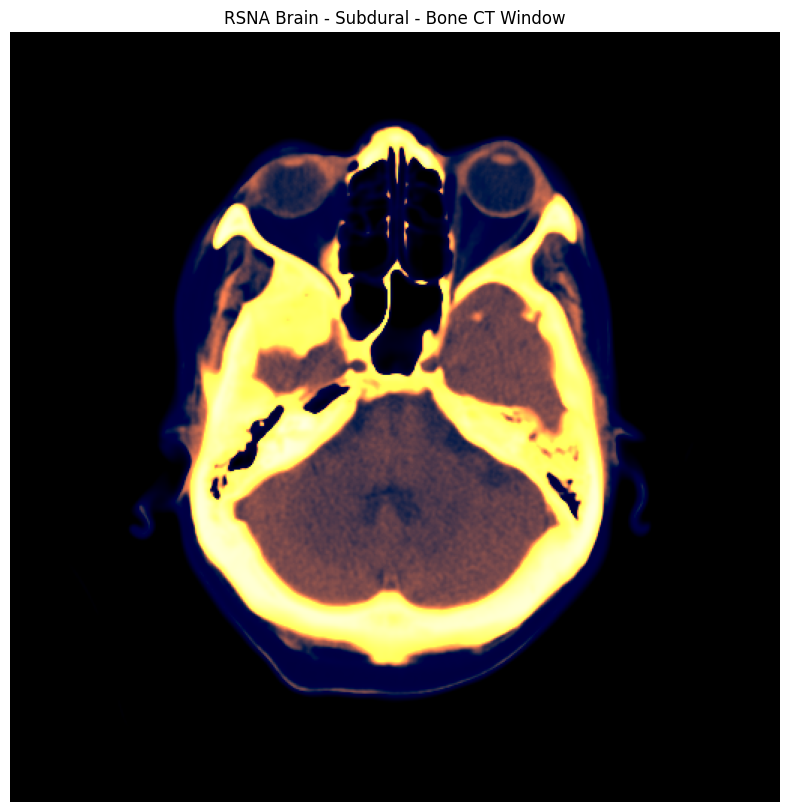

In [1]:
import pydicom
import glob
import numpy as np
import matplotlib.pyplot as plt

arama_yolu = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/*.dcm"
dosyalar = glob.glob(arama_yolu)

if len(dosyalar) > 0:
    hedef_dosya = dosyalar[0]
    print("Kilit kÄ±rÄ±ldÄ±, dosya negatif HU taramasÄ±yla iÅŸleniyor:", hedef_dosya)
    
    # --- TÄ±bbi Pencereleme FonksiyonlarÄ±mÄ±z ---
    def get_first(x):
        if type(x) == pydicom.multival.MultiValue: return int(x[0])
        return int(x)

    def window_image(img, center, width, intercept, slope):
        img = (img * slope + intercept)
        img_min = center - (width // 2)
        img_max = center + (width // 2)
        img[img < img_min] = img_min
        img[img > img_max] = img_max
        return (img - img_min) / (img_max - img_min)

    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]
    _, _, inter, slope = [get_first(x) for x in fields]
    
    # Ä°ÅžTE HAYAT KURTARAN TIP MÃœHENDÄ°SLÄ°ÄžÄ° DOKUNUÅžU:
    # "Negatif Doku yoÄŸunluklarÄ±na (Hava = -1024) izin ver"
    img = dataset.pixel_array.astype(float)
    
    red = window_image(img.copy(), 40, 80, inter, slope)       # Brain / Beyin Dokusu (KÄ±rmÄ±zÄ±)
    green = window_image(img.copy(), 80, 200, inter, slope)    # Subdural BÃ¶lge (YeÅŸil)
    blue = window_image(img.copy(), 600, 2800, inter, slope)   # Bone / KafatasÄ± (Mavi)
    
    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
    
    # --- Ekrana Ã‡izdirme ---
    plt.figure(figsize=(10,10))
    plt.imshow(rgb)
    plt.title("RSNA Brain - Subdural - Bone CT Window")
    plt.axis('off')
    plt.show()


In [2]:
import pandas as pd

# Cevap anahtarÄ±nÄ±n tam klasÃ¶r yolu
csv_yolu = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train.csv"

print("Cevap anahtarÄ± okunuyor... (Bu tablo biraz bÃ¼yÃ¼k, saniyeler sÃ¼rebilir)")
tanilar_tablosu = pd.read_csv(csv_yolu)

print("Klinik Tablo YÃ¼klendi! Toplam KayÄ±t SayÄ±sÄ±:", len(tanilar_tablosu))

# Tablonun en Ã¼stÃ¼ndeki ilk 10 radyoloji raporunu gÃ¶relim:
tanilar_tablosu.head(10)


Cevap anahtarÄ± okunuyor... (Bu tablo biraz bÃ¼yÃ¼k, saniyeler sÃ¼rebilir)
Klinik Tablo YÃ¼klendi! Toplam KayÄ±t SayÄ±sÄ±: 4516842


,ID,Label
0,ID_12cadc6af_epidural,0
1,ID_12cadc6af_intraparenchymal,0
2,ID_12cadc6af_intraventricular,0
3,ID_12cadc6af_subarachnoid,0
4,ID_12cadc6af_subdural,0
5,ID_12cadc6af_any,0
6,ID_38fd7baa0_epidural,0
7,ID_38fd7baa0_intraparenchymal,0
8,ID_38fd7baa0_intraventricular,0
9,ID_38fd7baa0_subarachnoid,0


In [3]:
print("Veriler tÄ±bbi hasta dosyasÄ± matrisine (Pivot) dÃ¶nÃ¼ÅŸtÃ¼rÃ¼lÃ¼yor. Bu iÅŸlem yaklaÅŸÄ±k 10-15 saniye sÃ¼rebilir...")

# 1. AynÄ± dosyadan mÃ¼kerrer girmeler yapÄ±lmÄ±ÅŸsa onlarÄ± silelim (Kaggle verisinde bu hata Ã§ok olur)
tanilar_tablosu = tanilar_tablosu.drop_duplicates(subset=['ID']).copy()

# 2. 'ID' sÃ¼tunundaki "_" iÅŸaretinden bÃ¶lerek "Hasta_ID" ve "Kanama_Tipi" olarak ikiye ayÄ±ralÄ±m
tanilar_tablosu[['Slice_ID', 'Hemorrhage_Type']] = tanilar_tablosu['ID'].str.rsplit('_', n=1, expand=True)

# 3. Pivot YapalÄ±m: Herkesin tek bir satÄ±rÄ± olsun, Kanama tipleri yanÄ±na sÃ¼tun olarak dizilsin
hasta_matrisi = tanilar_tablosu.pivot(index='Slice_ID', columns='Hemorrhage_Type', values='Label')

# Kafa karÄ±ÅŸÄ±klÄ±ÄŸÄ±nÄ± Ã¶nlemek iÃ§in sadece kanama sÃ¼tunlarÄ±nÄ± Ã¶ne alalÄ±m
hasta_matrisi = hasta_matrisi[['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']]

print("Ä°ÅŸlem BaÅŸarÄ±lÄ±! Ä°ÅŸte Yapay ZekanÄ±n AÅŸÄ±k OlacaÄŸÄ± O Harika TÄ±bbi Format:")
hasta_matrisi.head(10)


Veriler tÄ±bbi hasta dosyasÄ± matrisine (Pivot) dÃ¶nÃ¼ÅŸtÃ¼rÃ¼lÃ¼yor. Bu iÅŸlem yaklaÅŸÄ±k 10-15 saniye sÃ¼rebilir...
Ä°ÅŸlem BaÅŸarÄ±lÄ±! Ä°ÅŸte Yapay ZekanÄ±n AÅŸÄ±k OlacaÄŸÄ± O Harika TÄ±bbi Format:


Hemorrhage_Type,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
Slice_ID,,,,,,
ID_000012eaf,0,0,0,0,0,0
ID_000039fa0,0,0,0,0,0,0
ID_00005679d,0,0,0,0,0,0
ID_00008ce3c,0,0,0,0,0,0
ID_0000950d7,0,0,0,0,0,0
ID_0000aee4b,0,0,0,0,0,0
ID_0000ca2f6,0,0,0,0,0,0
ID_0000f1657,0,0,0,0,0,0
ID_000178e76,0,0,0,0,0,0


ðŸš¨ DÄ°KKAT: KanamalÄ± Hasta Bulundu!
Hasta NumarasÄ±: ID_0002081b6

UzmanlarÄ±n KoyduÄŸu TeÅŸhis Tablosu:
Hemorrhage_Type
any                 1
epidural            0
intraparenchymal    1
intraventricular    0
subarachnoid        0
subdural            0
Name: ID_0002081b6, dtype: int64


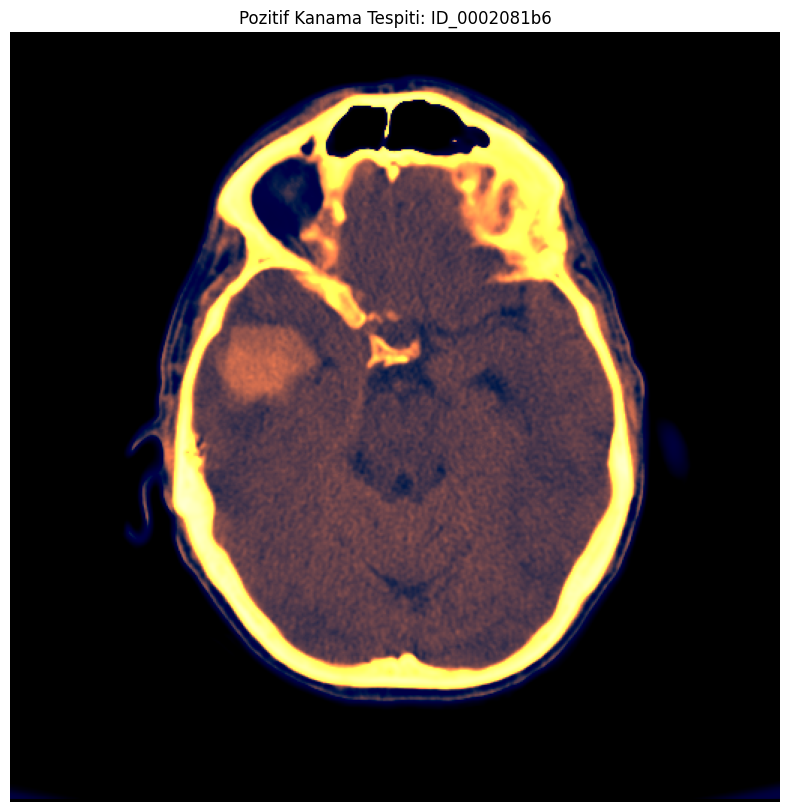

In [4]:
# matriste herhangi bir kanamasÄ± (any == 1) olan hastalarÄ± filtreleyelim
kanamali_hastalar = hasta_matrisi[hasta_matrisi['any'] == 1]

# KanamasÄ± olan Ä°LK hastanÄ±n numarasÄ±nÄ± alalÄ±m (Ã–rn: ID_xxxxxx)
kanamali_hasta_id = kanamali_hastalar.index[0]

print("ðŸš¨ DÄ°KKAT: KanamalÄ± Hasta Bulundu!")
print("Hasta NumarasÄ±:", kanamali_hasta_id)
print("\nUzmanlarÄ±n KoyduÄŸu TeÅŸhis Tablosu:")
print(kanamali_hastalar.loc[kanamali_hasta_id])

# Åžimdi adresini bulup resmini de ekrana basalÄ±m
hedef_dosya = f"/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/{kanamali_hasta_id}.dcm"

# Ã–nceki kodumuzda kullandÄ±ÄŸÄ±mÄ±z pencereleri aynen Ã§alÄ±ÅŸtÄ±rÄ±yoruz
dataset = pydicom.dcmread(hedef_dosya)
fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
          dataset[('0028','1052')].value, dataset[('0028','1053')].value]
_, _, inter, slope = [get_first(x) for x in fields]

img = dataset.pixel_array.astype(float)
red = window_image(img.copy(), 40, 80, inter, slope)       
green = window_image(img.copy(), 80, 200, inter, slope)    
blue = window_image(img.copy(), 600, 2800, inter, slope)   

rgb = np.zeros((img.shape[0], img.shape[1], 3))
rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue

plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.title(f"Pozitif Kanama Tespiti: {kanamali_hasta_id}")
plt.axis('off')
plt.show()


In [5]:
import math
import cv2
import tensorflow as tf
from tensorflow.keras.utils import Sequence

print("TaÅŸÄ±yÄ±cÄ± Bant Sistemi (Data Generator) Ä°nÅŸa Ediliyor...")

# BandÄ±n Ana MekanizmasÄ±
class RSNADataset(Sequence):
    def __init__(self, hasta_listesi, etiket_matrisi, batch_size=32, img_size=(256, 256)):
        self.hasta_listesi = hasta_listesi
        self.etiket_matrisi = etiket_matrisi
        self.batch_size = batch_size
        self.img_size = img_size
        self.dcm_dir = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/"
        
    def __len__(self):
        # TÃ¼m hastalarÄ±n kaÃ§ koliye sÄ±ÄŸacaÄŸÄ±nÄ± hesaplar
        return math.ceil(len(self.hasta_listesi) / self.batch_size)
    
    def __getitem__(self, idx):
        # Yapay zeka ne zaman "SÄ±radaki koli gelsin!" dese bu kÄ±sÄ±m Ã§alÄ±ÅŸÄ±r
        batch_ids = self.hasta_listesi[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        # X: GÃ¶rÃ¼ntÃ¼lerin yerleÅŸtirileceÄŸi kutu (Koli boyutu, En, Boy, 3 Renk kanalÄ±)
        X = np.zeros((len(batch_ids), self.img_size[0], self.img_size[1], 3)) 
        # Y: TÄ±bbi teÅŸhislerin listesi (Koli boyutu, 6 FarklÄ± hastalÄ±k sÃ¼tunu)
        Y = np.zeros((len(batch_ids), 6))
        
        for i, p_id in enumerate(batch_ids):
            dcm_path = self.dcm_dir + str(p_id) + ".dcm"
            try:
                # Tomografiyi okuyoruz
                dataset = pydicom.dcmread(dcm_path)
                fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
                          dataset[('0028','1052')].value, dataset[('0028','1053')].value]
                _, _, inter, slope = [get_first(x) for x in fields]
                
                img = dataset.pixel_array.astype(float)
                
                # 3 TÄ±bbi Pencereden geÃ§iriyoruz (Sizin uzmanlÄ±ÄŸÄ±nÄ±z olan adÄ±m)
                red = window_image(img.copy(), 40, 80, inter, slope)
                green = window_image(img.copy(), 80, 200, inter, slope)
                blue = window_image(img.copy(), 600, 2800, inter, slope)
                
                rgb = np.zeros((img.shape[0], img.shape[1], 3))
                rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
                
                # CT GÃ¶rÃ¼ntÃ¼leri normalde Ã§ok bÃ¼yÃ¼ktÃ¼r (512x512). Yapay zeka hÄ±zlansÄ±n diye 256x256 yapÄ±yoruz.
                rgb_resized = cv2.resize(rgb, self.img_size)
                
                X[i,] = rgb_resized
                Y[i,] = self.etiket_matrisi.loc[p_id].values
                
            except Exception as e:
                # EÄŸer Kaggle depolarÄ±nda dosyasÄ± bozuk bir hasta varsa sistemi Ã§Ã¶kertmemek iÃ§in gÃ¶rmezden gelir
                pass 
                
        return X, Y

print("âœ… Fabrika Ä°nÅŸa Edildi!")

# ----------------- SÄ°STEM TESTÄ° -----------------
# Tablomuzdaki tÃ¼m hastalarÄ±n numara listesini alalÄ±m
tam_hasta_listesi = hasta_matrisi.index.tolist()

# BandÄ± test edelim: Bir koliye sadece 8 hasta sÄ±ÄŸsÄ±n
test_bandi = RSNADataset(tam_hasta_listesi, hasta_matrisi, batch_size=8)

# DÃ¼ÄŸmeye basÄ±p banttan sÄ±radaki Ä°LK koliyi alalÄ±m:
ornek_resimler, ornek_teÅŸhisler = test_bandi[0]

print("\n--- Ä°lk Koli Teslim AlÄ±ndÄ± ---")
print("RÃ¶ntgen Paketinin Ã‡apÄ±:", ornek_resimler.shape)
print("TeÅŸhis Paketinin Ã‡apÄ±:", ornek_teÅŸhisler.shape)


2026-04-18 12:52:53.337943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776516773.686115      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776516773.781825      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776516774.627554      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776516774.627597      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776516774.627600      55 computation_placer.cc:177] computation placer alr

TaÅŸÄ±yÄ±cÄ± Bant Sistemi (Data Generator) Ä°nÅŸa Ediliyor...
âœ… Fabrika Ä°nÅŸa Edildi!

--- Ä°lk Koli Teslim AlÄ±ndÄ± ---
RÃ¶ntgen Paketinin Ã‡apÄ±: (8, 256, 256, 3)
TeÅŸhis Paketinin Ã‡apÄ±: (8, 6)


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("Uzman Zeka (EfficientNet) Laboratuvara Transfer Ediliyor...")

# 1. Eski tecrÃ¼beli beyni (EfficientNetB0) alÄ±yoruz.
# include_top=False: Eski karar mekanizmasÄ±nÄ± (kÃ¶pek/kedi/araba tanÄ±ma kÄ±smÄ±) kesip atar.
# weights='imagenet': Åžekilleri ve kenarlarÄ± Ã¶nceden Ã¶ÄŸrenmiÅŸ vizyon tecrÃ¼besini korur.
temel_beyin = EfficientNetB0(input_shape=(256, 256, 3), include_top=False, weights='imagenet')

# 2. Beynin Ã¼zerine kendi karar mekanizmamÄ±zÄ± (Hemorrhage) ekliyoruz
x = temel_beyin.output
x = GlobalAveragePooling2D()(x) # Trilyonlarca piksel bilgisini hÃ¼cre seviyesinde Ã¶zetler ve sÄ±kÄ±ÅŸtÄ±rÄ±r
x = Dropout(0.3)(x)             # TÄ±pta "AÅŸÄ±rÄ± ezberlemeyi" (Overfitting) Ã¶nlemek Ã§ok Ã¶nemlidir! Sisteme ufacÄ±k bir unutkanlÄ±k eÅŸiÄŸi ekliyoruz.

# 3. Nihai Karar Lobu: 6 farklÄ± hastalÄ±k (kanama) tipi iÃ§in baÄŸÄ±msÄ±z 6 adet Ã§Ä±kÄ±ÅŸ vanasÄ±!
# Sigmoid kullanÄ±yoruz ki: Hem Subdural 1, hem Epidural 1 olabilsin. Birbirini engellemesinler.
kesin_tanilar = Dense(6, activation='sigmoid')(x)

# VÃ¼cutla (Temel Beyin) Yeni KafayÄ± (Nihai Lob) cerrahi olarak birleÅŸtiriyoruz
bizim_model = Model(inputs=temel_beyin.input, outputs=kesin_tanilar)

# 4. AsistanÄ±n Ã§alÄ±ÅŸmaya baÅŸlama / Ã¶ÄŸrenme talimatlarÄ±
# tf.keras.optimizers.Adam: Hangi hÄ±zla Ã¶ÄŸreneceÄŸini belirler (Ã§ok yavaÅŸ olursa vakit biter, Ã§ok hÄ±zlÄ± olursa dersleri anlamaz)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005) 

# Sistemi derleyelim
bizim_model.compile(optimizer=optimizer, 
                    loss='binary_crossentropy', # Ã‡ok seÃ§meli ve birden fazla cevabÄ± olabilecek sÄ±navlar (Multi-label) iÃ§in en iyi puanlama yÃ¶ntemi
                    metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True)]) # DoÄŸruluk yÃ¼zdesi ve AUC skoru Ã§etelesi

print("\nâœ… Ve AsistanÄ±mÄ±zÄ±n Yeni Beyni Cerrahi Olarak HazÄ±rlandÄ±!")
print("Ä°ÅŸte beynin katmanlarÄ±nÄ±n rÃ¶ntgeni (Ã–zeti):")
bizim_model.summary()

Uzman Zeka (EfficientNet) Laboratuvara Transfer Ediliyor...


I0000 00:00:1776516810.122512      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776516810.128539      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 1s 0us/step

âœ… Ve AsistanÄ±mÄ±zÄ±n Yeni Beyni Cerrahi Olarak HazÄ±rlandÄ±!
Ä°ÅŸte beynin katmanlarÄ±nÄ±n rÃ¶ntgeni (Ã–zeti):


Model: "functional"

â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”³â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”“
â”ƒ Layer (type)        â”ƒ Output Shape      â”ƒ    Param # â”ƒ Connected to      â”ƒ
â”¡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â•‡â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”©
â”‚ input_layer         â”‚ (None, 256, 256,  â”‚          0 â”‚ -                 â”‚
â”‚ (InputLayer)        â”‚ 3)                â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ rescaling           â”‚ (None, 256, 256,  â”‚          0 â”‚ input_layer[0][0] â”‚
â”‚ (Rescaling)         â”‚ 3)                â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ normalization       â”‚ (None, 256, 256,  â”‚          7 â”‚ rescaling[0][0]   â”‚
â”‚ (Normalization)     â”‚ 3)                â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ rescaling_1         â”‚ (None, 256, 256,  â”‚          0 â”‚ normalization[0]â€¦ â”‚
â”‚ (Rescaling)         â”‚ 3)                â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ stem_conv_pad       â”‚ (None, 257, 257,  â”‚          0 â”‚ rescaling_1[0][0] â”‚
â”‚ (ZeroPadding2D)     â”‚ 3)                â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ stem_conv (Conv2D)  â”‚ (None, 128, 128,  â”‚        864 â”‚ stem_conv_pad[0]â€¦ â”‚
â”‚                     â”‚ 32)               â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ stem_bn             â”‚ (None, 128, 128,  â”‚        128 â”‚ stem_conv[0][0]   â”‚
â”‚ (BatchNormalizatioâ€¦ â”‚ 32)               â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ stem_activation     â”‚ (None, 128, 128,  â”‚          0 â”‚ stem_bn[0][0]     â”‚
â”‚ (Activation)        â”‚ 32)               â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¼â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”¤
â”‚ block1a_dwconv      â”‚ (None, 128, 128,  â”‚        288 â”‚ stem_activation[â€¦ â”‚
â”‚ (DepthwiseConv2D)   â”‚ 32)               â”‚            â”‚                   â”‚
â”œâ”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 4,015,234 (15.32 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
print("EÄŸitim SÃ¼reci (Asistan AsistanlÄ±ÄŸÄ±) BaÅŸlÄ±yor...")

# TaÅŸÄ±yÄ±cÄ± bantÄ±mÄ±zÄ± standart fabrika ayarlarÄ±na (Koli baÅŸÄ± 32 Hasta) getirelim
orijinal_egitim_bandi = RSNADataset(tam_hasta_listesi, hasta_matrisi, batch_size=32)

# AsistanÄ±n derse oturduÄŸu an! 
# Epochs: KitabÄ± baÅŸtan sona kaÃ§ kere okuyacaÄŸÄ± (1 yeterli)
# steps_per_epoch: KitabÄ±n tamamÄ±nÄ± deÄŸil de, ÅŸimdilik sadece ilk 50 sayfayÄ± (koliyi) okuyup bÄ±rakmasÄ± iÃ§in.
history = bizim_model.fit(
    orijinal_egitim_bandi, 
    epochs=1,
    steps_per_epoch=50,
    verbose=1
)

print("\nðŸŽ¯ Harika! Asistan 1600 hastayÄ± (50 Koli) dakikalar iÃ§inde inceledi ve eÄŸitim aÅŸamasÄ±nÄ± kavradÄ±.")


EÄŸitim SÃ¼reci (Asistan AsistanlÄ±ÄŸÄ±) BaÅŸlÄ±yor...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1776516851.465232     137 service.cc:152] XLA service 0x7dc8b40047b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776516851.465277     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776516851.465284     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776516858.047152     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-18 12:54:29.545035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal

50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 124s 708ms/step - accuracy: 0.5537 - auc: 0.6339 - loss: 0.3267

ðŸŽ¯ Harika! Asistan 1600 hastayÄ± (50 Koli) dakikalar iÃ§inde inceledi ve eÄŸitim aÅŸamasÄ±nÄ± kavradÄ±.


2026-04-18 13:04:32.699197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:04:32.834084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:04:33.598521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:04:33.732947: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 13:04:33.867651: E external/local_xla/xla/stream_

1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 11s 11s/step

   ðŸ‘¨â€âš•ï¸ UZMAN DOKTOR VS ðŸ¤– YAPAY ZEKA   
   HASTA: ID_0002081b6

ðŸ©¸ ANY                | ðŸ‘¨â€âš•ï¸ UZMAN: VAR  | ðŸ¤– ASÄ°STAN: % 63.3 ÅžÃ¼phe
ðŸ©¸ EPIDURAL           | ðŸ‘¨â€âš•ï¸ UZMAN: Yok  | ðŸ¤– ASÄ°STAN: % 65.0 ÅžÃ¼phe
ðŸ©¸ INTRAPARENCHYMAL   | ðŸ‘¨â€âš•ï¸ UZMAN: VAR  | ðŸ¤– ASÄ°STAN: % 62.6 ÅžÃ¼phe
ðŸ©¸ INTRAVENTRICULAR   | ðŸ‘¨â€âš•ï¸ UZMAN: Yok  | ðŸ¤– ASÄ°STAN: % 60.7 ÅžÃ¼phe
ðŸ©¸ SUBARACHNOID       | ðŸ‘¨â€âš•ï¸ UZMAN: Yok  | ðŸ¤– ASÄ°STAN: % 55.6 ÅžÃ¼phe
ðŸ©¸ SUBDURAL           | ðŸ‘¨â€âš•ï¸ UZMAN: Yok  | ðŸ¤– ASÄ°STAN: % 63.5 ÅžÃ¼phe


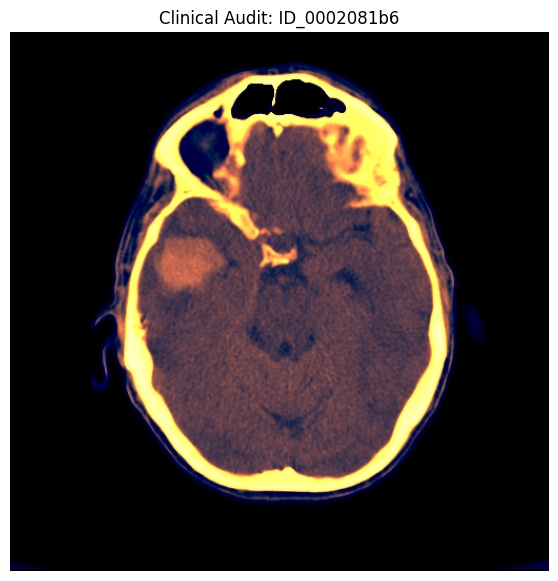

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Daha Ã¶nce bulduÄŸumuz o kanamalÄ± hastayÄ± (ID_27a354d42) tekrar viziteye Ã§aÄŸÄ±rÄ±yoruz
secili_hasta_id = kanamali_hasta_id  

# Masadaki GerÃ§ek TÄ±bbi Raporumuz (Cevap AnahtarÄ±mÄ±z)
gercek_tanilar = hasta_matrisi.loc[secili_hasta_id]

# HastanÄ±n Tomografisini ArÅŸivden AlalÄ±m
hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + secili_hasta_id + ".dcm"

# HÄ±zlÄ±ca Pencereleri Ã‡izelim (AsistanÄ±n gÃ¶zlÃ¼ÄŸÃ¼nÃ¼ takalÄ±m)
dataset = pydicom.dcmread(hedef_dosya)
fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
          dataset[('0028','1052')].value, dataset[('0028','1053')].value]
_, _, inter, slope = [get_first(x) for x in fields]

img = dataset.pixel_array.astype(float)
red = window_image(img.copy(), 40, 80, inter, slope)
green = window_image(img.copy(), 80, 200, inter, slope)
blue = window_image(img.copy(), 600, 2800, inter, slope)

rgb = np.zeros((img.shape[0], img.shape[1], 3))
rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue

# Yapay Zeka iÃ§in yeniden boyutlandÄ±rma
rgb_resized = cv2.resize(rgb, (256, 256))

# Yapay zekaya bu resmi sanki 1 kiÅŸilik bir yÄ±ÄŸÄ±nmÄ±ÅŸ (batch) gibi klasÃ¶re koyup gÃ¶nderelim
yapay_zeka_verisi = np.expand_dims(rgb_resized, axis=0)

# ================================
# ASÄ°STANIN FÄ°KRÄ°NÄ° ALIYORUZ!
tahminler = bizim_model.predict(yapay_zeka_verisi)
# ================================

kanama_tipleri = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

print(f"\n=============================================")
print(f"   ðŸ‘¨â€âš•ï¸ UZMAN DOKTOR VS ðŸ¤– YAPAY ZEKA   ")
print(f"   HASTA: {secili_hasta_id}")
print(f"=============================================\n")

for i, tip in enumerate(kanama_tiplerizzz):
    # EÄŸer cevap anahtarÄ± 1 ise VAR, 0 ise YOK yazalÄ±m
    gercek_sonuc = "VAR" if gercek_tanilar[tip] == 1 else "Yok "
    
    # AsistanÄ±n cevabÄ±nÄ± (0.00 ile 1.00 arasÄ± deÄŸiÅŸen sayÄ±yÄ±) YÃ¼zdeye (%) Ã§evirelim
    asistan_tahmini = tahminler[0][i] * 100 
    
    # KarÅŸÄ±laÅŸtÄ±rmalÄ± Ekrana YazdÄ±ralÄ±m
    print(f"ðŸ©¸ {tip.ljust(16).upper()}   | ðŸ‘¨â€âš•ï¸ UZMAN: {gercek_sonuc.ljust(4)} | ðŸ¤– ASÄ°STAN: % {asistan_tahmini:.1f} ÅžÃ¼phe")

# Ve GÃ¶rsel Olarak HastayÄ± da GÃ¶sterelim
plt.figure(figsize=(7,7))
plt.imshow(rgb)
plt.title(f"Clinical Audit: {secili_hasta_id}")
plt.axis('off')
plt.show()


Bilimsel KanÄ±t (Learning Curve) AÅŸamasÄ± BaÅŸlÄ±yor...
Epoch 1/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 37s 728ms/step - accuracy: 0.7485 - auc: 0.7710 - loss: 0.1505
Epoch 2/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 37s 744ms/step - accuracy: 0.8008 - auc: 0.7807 - loss: 0.1456
Epoch 3/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 37s 742ms/step - accuracy: 0.8826 - auc: 0.8112 - loss: 0.1481
Epoch 4/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 36s 715ms/step - accuracy: 0.8719 - auc: 0.8497 - loss: 0.1157
Epoch 5/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 44s 878ms/step - accuracy: 0.8470 - auc: 0.8730 - loss: 0.1428


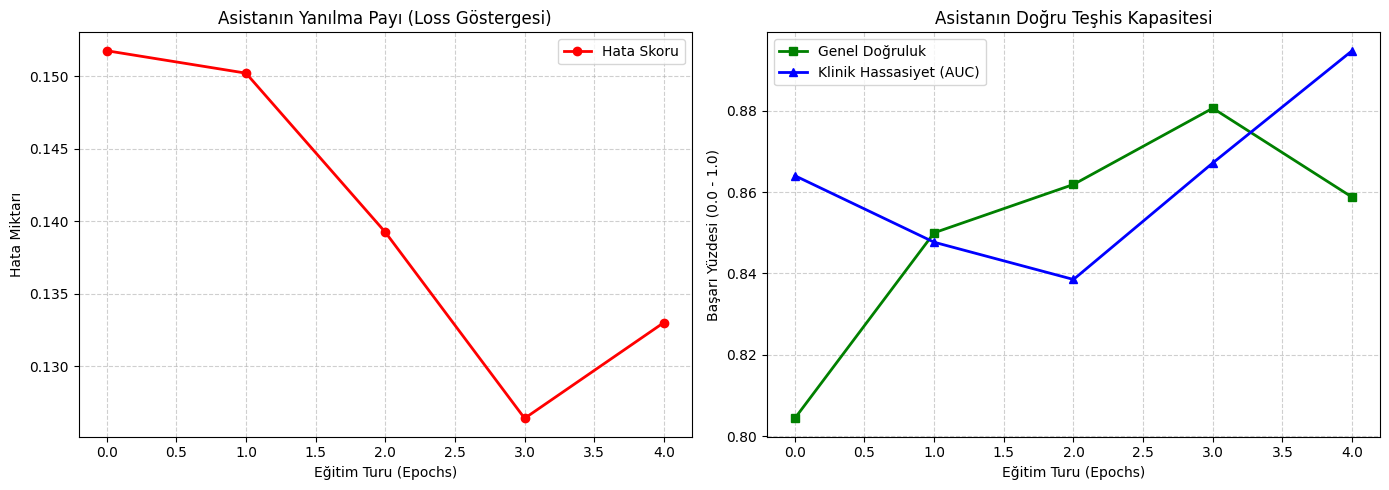


âœ… MÃ¼kemmel! AsistanÄ±n zaman geÃ§tikÃ§e nasÄ±l uzmanlaÅŸtÄ±ÄŸÄ±nÄ± bilimsel grafiklerle ispatladÄ±nÄ±z.


In [9]:
import matplotlib.pyplot as plt

print("Bilimsel KanÄ±t (Learning Curve) AÅŸamasÄ± BaÅŸlÄ±yor...")

# AsistanÄ±n okuyacaÄŸÄ± kitap sayÄ±sÄ±nÄ± artÄ±rÄ±yoruz. 
# 5 Tur (Epoch) boyunca hastalarÄ± tekrar tekrar inceleyecek ve her seferinde kendini dÃ¼zeltecek.
GELISMIS_EGITIM_TURU = 5
GELISMIS_TEST_ADIMI = 50 # Her turda 50 koli tomografi okuyacak

# Asistan ders programÄ±na (Fit) geri dÃ¶nÃ¼yor
history = bizim_model.fit(
    orijinal_egitim_bandi, 
    epochs=GELISMIS_EGITIM_TURU,
    steps_per_epoch=GELISMIS_TEST_ADIMI,
    verbose=1
)

# -----------------------------------------------------
# EÄžÄ°TÄ°M BÄ°TTÄ° -> ÅžÄ°MDÄ° BUNU KLÄ°NÄ°K GRAFÄ°ÄžE DÃ–KÃœYORUZ
# -----------------------------------------------------
plt.figure(figsize=(14, 5))

# 1. Grafik: AsistanÄ±n Hata PayÄ± (Loss) - Zamanla dÃ¼ÅŸmesi beklenir!
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Hata Skoru', color='red', linewidth=2, marker='o')
plt.title('AsistanÄ±n YanÄ±lma PayÄ± (Loss GÃ¶stergesi)')
plt.xlabel('EÄŸitim Turu (Epochs)')
plt.ylabel('Hata MiktarÄ±')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Grafik: AsistanÄ±n TeÅŸhis BaÅŸarÄ±sÄ± (Accuracy ve AUC) - Zamanla yÃ¼kselmesi beklenir!
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Genel DoÄŸruluk', color='green', linewidth=2, marker='s')
plt.plot(history.history['auc'], label='Klinik Hassasiyet (AUC)', color='blue', linewidth=2, marker='^')
plt.title('AsistanÄ±n DoÄŸru TeÅŸhis Kapasitesi')
plt.xlabel('EÄŸitim Turu (Epochs)')
plt.ylabel('BaÅŸarÄ± YÃ¼zdesi (0.0 - 1.0)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

print("\nâœ… MÃ¼kemmel! AsistanÄ±n zaman geÃ§tikÃ§e nasÄ±l uzmanlaÅŸtÄ±ÄŸÄ±nÄ± bilimsel grafiklerle ispatladÄ±nÄ±z.")


SÄ±nav KaÄŸÄ±tlarÄ± HazÄ±rlanÄ±yor (EÄŸitim DÄ±ÅŸÄ± Verilerden)...
SÄ±nav BaÅŸladÄ±! 5 HastanÄ±n Tomografisi Ä°nceleniyor...



/tmp/ipykernel_55/3341629957.py:79: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/3341629957.py:79: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/3341629957.py:79: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/3341629957.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packa

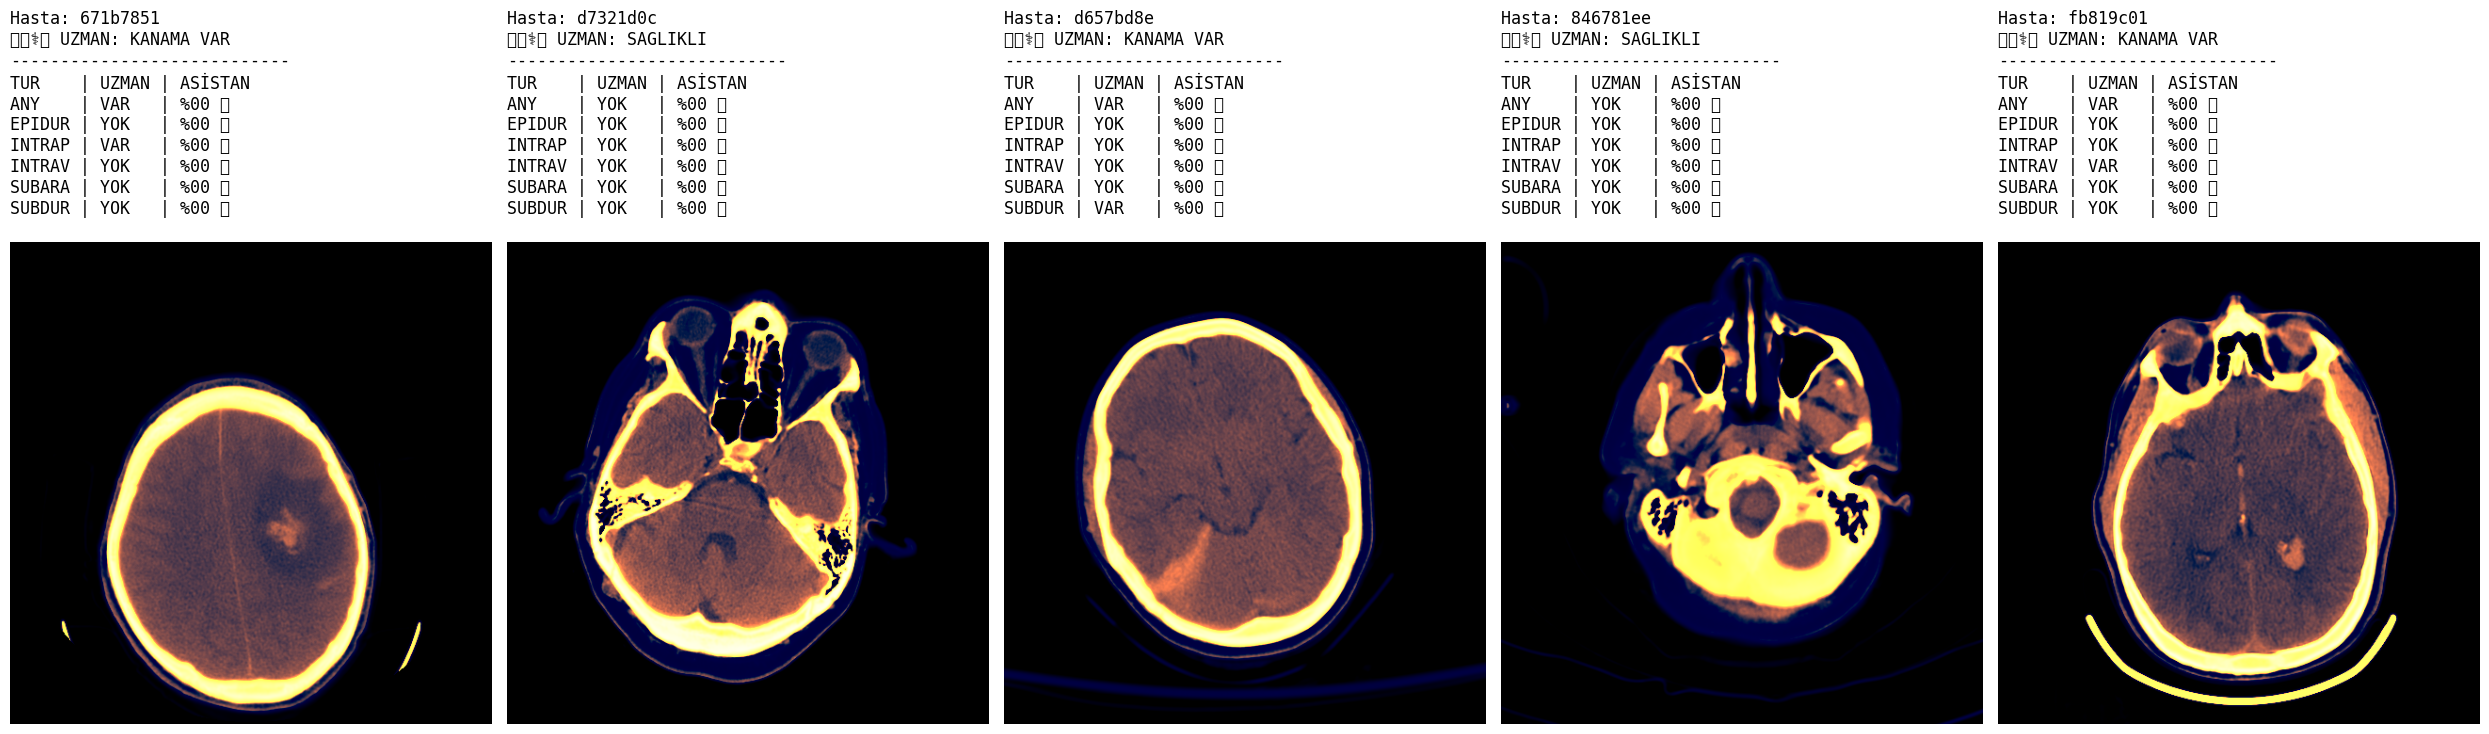

In [11]:
import random

print("SÄ±nav KaÄŸÄ±tlarÄ± HazÄ±rlanÄ±yor (EÄŸitim DÄ±ÅŸÄ± Verilerden)...")

# Asistan sadece ilk 1600 hastayÄ± gÃ¶rmÃ¼ÅŸtÃ¼. Biz 2000. sÄ±radan sonrasÄ±na gidiyoruz!
hic_gorulmeden_kalanlar = tam_hasta_listesi[2000:]

# 3 Adet Rastgele KanamalÄ± Hasta BulalÄ±m
kanamali_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
kanamali_havuz = kanamali_havuz[kanamali_havuz['any'] == 1].index.tolist()
sinav_kanamalilar = random.sample(kanamali_havuz, 3)

# 2 Adet Rastgele SapasaÄŸlam Hasta BulalÄ±m
saglam_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
saglam_havuz = saglam_havuz[saglam_havuz['any'] == 0].index.tolist()
sinav_saglamlar = random.sample(saglam_havuz, 2)

# SÄ±nav DosyasÄ±nÄ± BirleÅŸtirip KarÄ±ÅŸtÄ±ralÄ±m ki Kopya Ã‡ekemesin!
sinav_hastalar = sinav_kanamalilar + sinav_saglamlar
random.shuffle(sinav_hastalar) 

print("SÄ±nav BaÅŸladÄ±! 5 HastanÄ±n Tomografisi Ä°nceleniyor...\n")

kanama_tipleri = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# 5 HastayÄ± yan yana gÃ¶stermek iÃ§in geniÅŸ bir tablo Ã§iziyoruz
fig, axes = plt.subplots(1, 5, figsize=(25, 7))

for i, hasta_id in enumerate(sinav_hastalar):
    gercek_tanilar = hasta_matrisi.loc[hasta_id]
    hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + hasta_id + ".dcm"
    
    # Pencereleri Giydirme
    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]
    _, _, inter, slope = [get_first(x) for x in fields]

    img = dataset.pixel_array.astype(float)
    red = window_image(img.copy(), 40, 80, inter, slope)
    green = window_image(img.copy(), 80, 200, inter, slope)
    blue = window_image(img.copy(), 600, 2800, inter, slope)

    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
    
    # 256x256 modele uygun kÃ¼Ã§Ã¼ltme
    rgb_resized = cv2.resize(rgb, (256, 256))
    yapay_zeka_verisi = np.expand_dims(rgb_resized, axis=0)
    
    # ================================
    # ASÄ°STAN CEVAPLIYOR (Predict)
    tahmin_yuzdeleri = bizim_model.predict(yapay_zeka_verisi, verbose=0)[0]
    # ================================

    # Ã‡Ä±ktÄ±larÄ± YazdÄ±rma
    ax = axes[i]
    ax.imshow(rgb)
    ax.axis('off')
    
    gercek_any = "KANAMA VAR" if gercek_tanilar['any'] == 1 else "SAGLIKLI"
    
    # TÄ±bbi SÄ±nav Raporu
    rapor = f"Hasta: {hasta_id[-8:]}\n"
    rapor += f"ðŸ‘¨â€âš•ï¸ UZMAN: {gercek_any}\n"
    rapor += '-'*28 + '\n'
    rapor += "TUR    | UZMAN | ASÄ°STAN\n"
    
    for idx, tip in enumerate(kanama_tipleri):
        g = "VAR " if gercek_tanilar[tip] == 1 else "YOK "
        t_yuzde = tahmin_yuzdeleri[idx] * 100
        # AsistanÄ±n kararÄ± %50 Ã¼zerindeyse tehlike var demektir
        t_karar = "ðŸš¨" if t_yuzde > 50 else "âœ…"
        
        rapor += f"{tip[:6].upper().ljust(6)} | {g}  | %{t_yuzde:02.0f} {t_karar}\n"
        
    ax.set_title(rapor, loc='left', fontsize=12, fontfamily='monospace')

plt.tight_layout()
plt.show()


In [12]:
import random

print("BaÅŸhekimin Emriyle SÄ±nÄ±f DengesizliÄŸi (Class Imbalance / Hile) Ã‡Ã¶zÃ¼lÃ¼yor...")

# 1. KanamalÄ± ve SaÄŸlam hastalar havuzunu tamamen ikiye ayÄ±ralÄ±m
kanamali_havuz_tam = hasta_matrisi[hasta_matrisi['any'] == 1].index.tolist()
saglikli_havuz_tam = hasta_matrisi[hasta_matrisi['any'] == 0].index.tolist()

# 2. "Åžok SÄ±navÄ±" DosyasÄ± (Tam 800 KanamalÄ± + 800 SaÄŸlÄ±klÄ± = YarÄ± YarÄ±ya DaÄŸÄ±lÄ±m)
dengeli_hastalar = kanamali_havuz_tam[:800] + saglikli_havuz_tam[:800]

# Asistan kalÄ±bÄ± ezberlemesin diye kaÄŸÄ±tlarÄ±n sÄ±rasÄ±nÄ± iyice karÄ±ÅŸtÄ±ralÄ±m
random.shuffle(dengeli_hastalar)

# 3. YÃ¼rÃ¼yen BandÄ± bu "Torpilsiz ve Dengeli" listeyle yeniden kuralÄ±m
dengeli_egitim_bandi = RSNADataset(dengeli_hastalar, hasta_matrisi, batch_size=32)

print("\nKoli Ä°Ã§eriÄŸi DÃ¼zeltildi! Bantta ArtÄ±k YarÄ± YarÄ±ya Hasta Var.")
print("AsistanÄ±n Beynindeki Eski Temel Tembellikleri Silip, EÄŸitime AlÄ±yoruz...")

# ----- YENÄ° VE TEMÄ°Z BÄ°R BEYÄ°N -----
x = temel_beyin.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
kesin_tanilar = tf.keras.layers.Dense(6, activation='sigmoid')(x)

yeni_asistan = tf.keras.models.Model(inputs=temel_beyin.input, outputs=kesin_tanilar)
yeni_asistan.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                     loss='binary_crossentropy', 
                     metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True)])
# -----------------------------------

# Åžimdi Dengeli Hileyi KÄ±rma EÄŸitimi BaÅŸlasÄ±n (Test adÄ±mÄ± belirtmiyoruz Ã§Ã¼nkÃ¼ listeyi tam 1600 verdik zaten)
history_yeni = yeni_asistan.fit(
    dengeli_egitim_bandi, 
    epochs=5,
    verbose=1
)

# EÄŸitilen asistanÄ±, asÄ±l modelimizin Ã¼stÃ¼ne kaydedelim ki Ä±sÄ± haritasÄ± bu dÃ¼zelmiÅŸ modelle Ã§alÄ±ÅŸsÄ±n
bizim_model = yeni_asistan

print("\nModelin tembelliÄŸi kÄ±rÄ±ldÄ±! Asistan mecburen ter dÃ¶kerek tÃ¼m kanamalarÄ± ayÄ±rt etmeyi Ã§alÄ±ÅŸtÄ±.")

BaÅŸhekimin Emriyle SÄ±nÄ±f DengesizliÄŸi (Class Imbalance / Hile) Ã‡Ã¶zÃ¼lÃ¼yor...

Koli Ä°Ã§eriÄŸi DÃ¼zeltildi! Bantta ArtÄ±k YarÄ± YarÄ±ya Hasta Var.
AsistanÄ±n Beynindeki Eski Temel Tembellikleri Silip, EÄŸitime AlÄ±yoruz...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 106s 714ms/step - accuracy: 0.7878 - auc_1: 0.6850 - loss: 0.4058
Epoch 2/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 424ms/step - accuracy: 0.8770 - auc_1: 0.8849 - loss: 0.2608
Epoch 3/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 424ms/step - accuracy: 0.7665 - auc_1: 0.9300 - loss: 0.1967
Epoch 4/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 22s 429ms/step - accuracy: 0.6091 - auc_1: 0.9638 - loss: 0.1453
Epoch 5/5
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 421ms/step - accuracy: 0.5141 - auc_1: 0.9872 - loss: 0.0929

Modelin tembelliÄŸi kÄ±rÄ±ldÄ±! Asistan mecburen ter dÃ¶kerek tÃ¼m kanamalarÄ± ayÄ±rt etmeyi Ã§alÄ±ÅŸtÄ±.


Åžok EÄŸitiminden Ã‡Ä±kmÄ±ÅŸ AsistanÄ±n Yeni '5 HastalÄ±k SÄ±navÄ±' BaÅŸlÄ±yor...


/tmp/ipykernel_55/108181471.py:80: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/108181471.py:80: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/108181471.py:80: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/108181471.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/

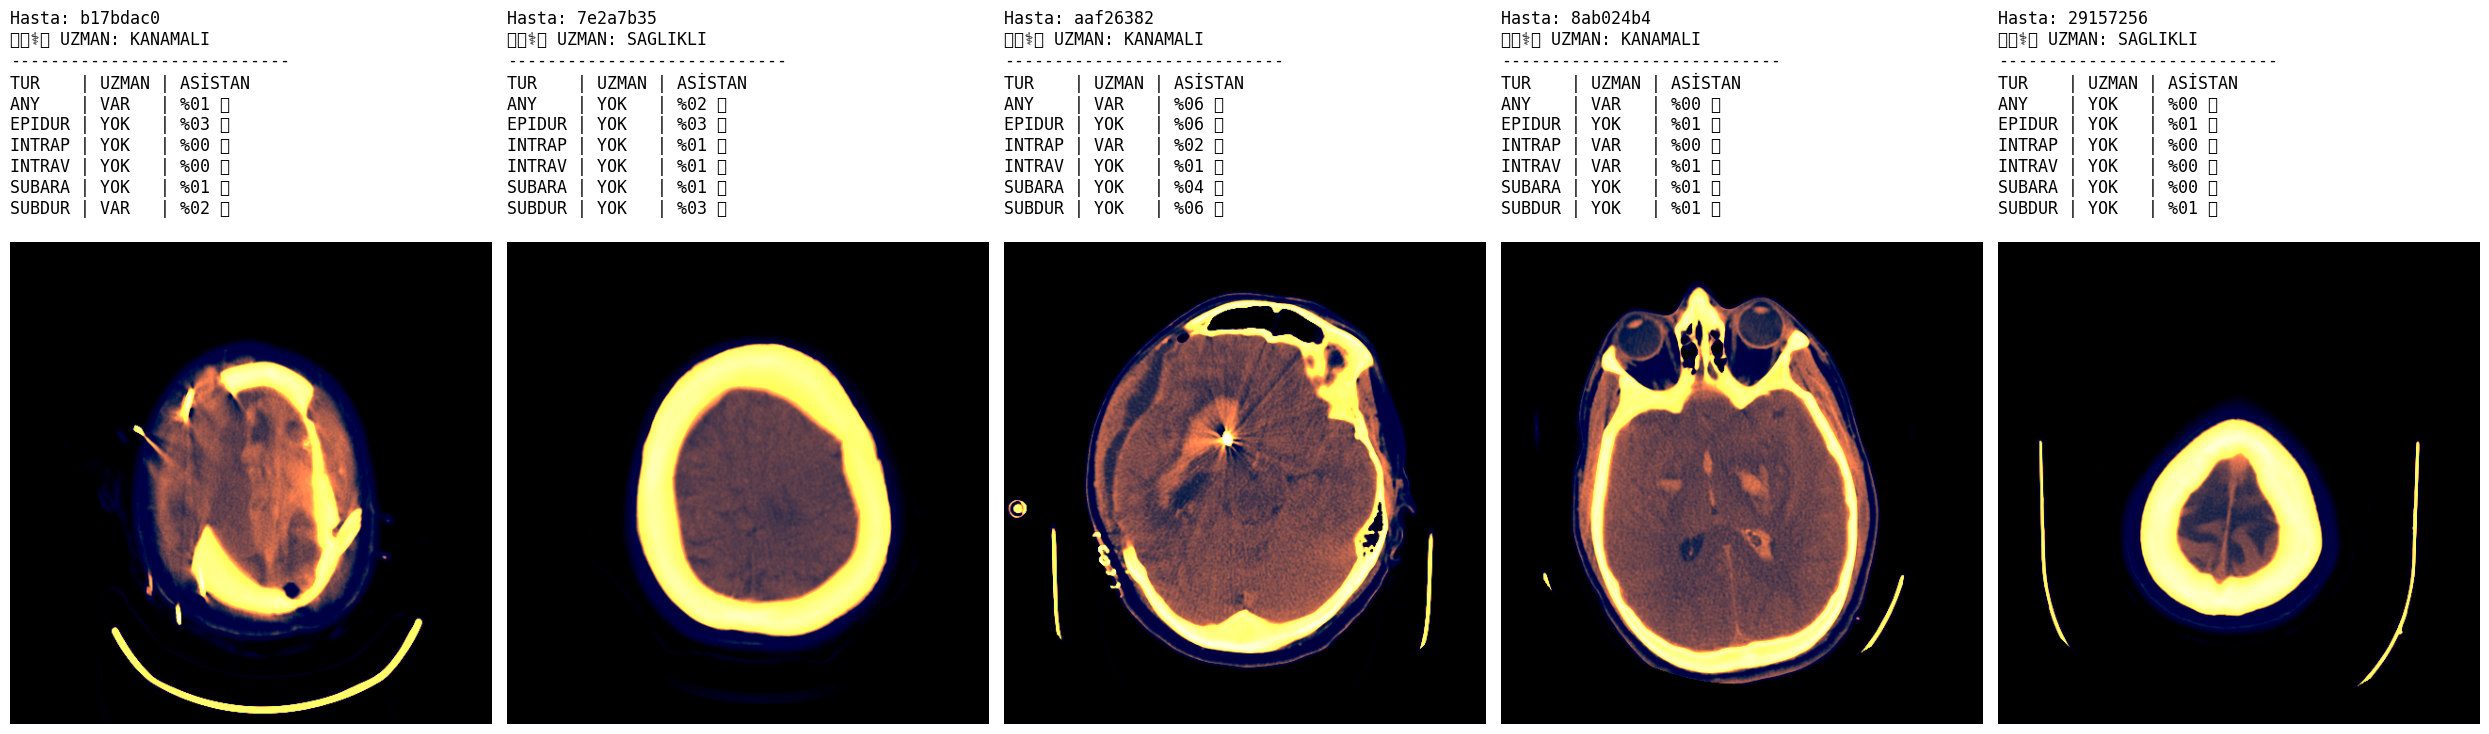

In [13]:
import random
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("Åžok EÄŸitiminden Ã‡Ä±kmÄ±ÅŸ AsistanÄ±n Yeni '5 HastalÄ±k SÄ±navÄ±' BaÅŸlÄ±yor...")

# AsistanÄ±n yeni dengeli eÄŸitimde de gÃ¶rmediÄŸi havuzdan rastgele 5 yeni kiÅŸi (Unseen)
hic_gorulmeden_kalanlar = tam_hasta_listesi[2000:]

kanamali_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
kanamali_havuz = kanamali_havuz[kanamali_havuz['any'] == 1].index.tolist()
sinav_kanamalilar = random.sample(kanamali_havuz, 3) # 3 KanamalÄ± Hasta

saglam_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
saglam_havuz = saglam_havuz[saglam_havuz['any'] == 0].index.tolist()
sinav_saglamlar = random.sample(saglam_havuz, 2) # 2 SaÄŸlÄ±klÄ± Hasta

# SÄ±nav DosyasÄ±nÄ± KarÄ±ÅŸtÄ±r (Asistan kaÃ§ kiÅŸi saÄŸlÄ±klÄ± bilmiyor)
sinav_hastalar = sinav_kanamalilar + sinav_saglamlar
random.shuffle(sinav_hastalar) 

kanama_tipleri = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

fig, axes = plt.subplots(1, 5, figsize=(25, 7))

for i, hasta_id in enumerate(sinav_hastalar):
    gercek_tanilar = hasta_matrisi.loc[hasta_id]
    hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + hasta_id + ".dcm"
    
    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]
    
    def get_first_local(x):
        if type(x) == pydicom.multival.MultiValue: return int(x[0])
        return int(x)

    _, _, inter, slope = [get_first_local(x) for x in fields]

    img = dataset.pixel_array.astype(float)
    red = window_image(img.copy(), 40, 80, inter, slope)
    green = window_image(img.copy(), 80, 200, inter, slope)
    blue = window_image(img.copy(), 600, 2800, inter, slope)

    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
    
    rgb_resized = cv2.resize(rgb, (256, 256))
    yapay_zeka_verisi = np.expand_dims(rgb_resized, axis=0)
    
    # ====================================================
    # YENÄ° (DENGELÄ°) MODEL Ä°LE TAHMÄ°N
    tahmin_yuzdeleri = bizim_model.predict(yapay_zeka_verisi, verbose=0)[0]
    # ====================================================
    
    ax = axes[i]
    ax.imshow(rgb)
    ax.axis('off')
    
    gercek_any = "KANAMALI" if gercek_tanilar['any'] == 1 else "SAGLIKLI"
    
    rapor = f"Hasta: {hasta_id[-8:]}\n"
    rapor += f"ðŸ‘¨â€âš•ï¸ UZMAN: {gercek_any}\n"
    rapor += '-'*28 + '\n'
    rapor += "TUR    | UZMAN | ASÄ°STAN\n"
    
    for idx, tip in enumerate(kanama_tipleri):
        g = "VAR " if gercek_tanilar[tip] == 1 else "YOK "
        t_yuzde = tahmin_yuzdeleri[idx] * 100
        
        # EÄžER ASÄ°STAN %50'DEN ÅžÃœPHELÄ°YSE ALARM (ðŸš¨), EMÄ°NSE (âœ…) VERSÄ°N
        t_karar = "ðŸš¨" if t_yuzde >= 50 else "âœ…"
        
        rapor += f"{tip[:6].upper().ljust(6)} | {g}  | %{t_yuzde:02.0f} {t_karar}\n"
        
    ax.set_title(rapor, loc='left', fontsize=12, fontfamily='monospace')

plt.tight_layout()
plt.show()


In [16]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pydicom

print("TÄ±bbi Anatomik (IsÄ± HaritasÄ± / Grad-CAM) Analizi BaÅŸlÄ±yor...\n")

# Modeldeki son "gÃ¶rÃ¼ntÃ¼ algÄ±lama" (GÃ¶z) katmanÄ±nÄ± buluyoruz:
son_gorsel_katman_adi = None
for layer in reversed(bizim_model.layers):
    if len(layer.output_shape) == 4:
        son_gorsel_katman_adi = layer.name
        break

print(f"AsistanÄ±n GÃ¶z Sinir UÃ§larÄ± Bulundu: {son_gorsel_katman_adi}")

def isi_haritasi_cikar(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # Karar verilen en gÃ¼Ã§lÃ¼ hastalÄ±k skorunu hedef al
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Test iÃ§in meÅŸhur kanamalÄ± hastamÄ±zÄ± alalÄ±m
ornek_hasta_id = kanamali_hastalar.index[0]
hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + ornek_hasta_id + ".dcm"

# GÃ¶rÃ¼ntÃ¼yÃ¼ Sizin Profesyonel Pencerelerinizden GeÃ§irelim
dataset = pydicom.dcmread(hedef_dosya)
fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
          dataset[('0028','1052')].value, dataset[('0028','1053')].value]

def get_first_local(x):
    if type(x) == pydicom.multival.MultiValue: return int(x[0])
    return int(x)

_, _, inter, slope = [get_first_local(x) for x in fields]

img = dataset.pixel_array.astype(float)
red = window_image(img.copy(), 40, 80, inter, slope)
green = window_image(img.copy(), 80, 200, inter, slope)
blue = window_image(img.copy(), 600, 2800, inter, slope)

rgb = np.zeros((img.shape[0], img.shape[1], 3))
rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue

rgb_resized = cv2.resize(rgb, (256, 256))
img_array = np.expand_dims(rgb_resized, axis=0)

# ---------------------------------------------
# Ä°ÅžTE MUCÄ°ZE BURADA: AsistanÄ± IsÄ± HaritasÄ±na Zorla!
heatmap = isi_haritasi_cikar(img_array, bizim_model, son_gorsel_katman_adi)
# ---------------------------------------------

# HaritayÄ± Ã‡izilebilir Formata Getirme (KÄ±rmÄ±zÄ±/SarÄ± = YÃ¼ksek Odak, Mavi/Lacivert = BoÅŸ BakÄ±ÅŸ)
heatmap_resized = cv2.resize(heatmap, (rgb.shape[1], rgb.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
jet = plt.colormaps.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

superimposed_img = jet_heatmap * 0.4 + rgb
superimposed_img = np.clip(superimposed_img, 0, 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title(f"A) UZMAN (SÄ°ZÄ°N) CT GÃ–RÃœNTÃœNÃœZ")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("B) ASÄ°STANIN TEÅžHÄ°S KOYARKEN BAKTIÄžI YER")
plt.axis('off')

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

TÄ±bbi Anatomik (IsÄ± HaritasÄ± / Grad-CAM) Analizi BaÅŸlÄ±yor...



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


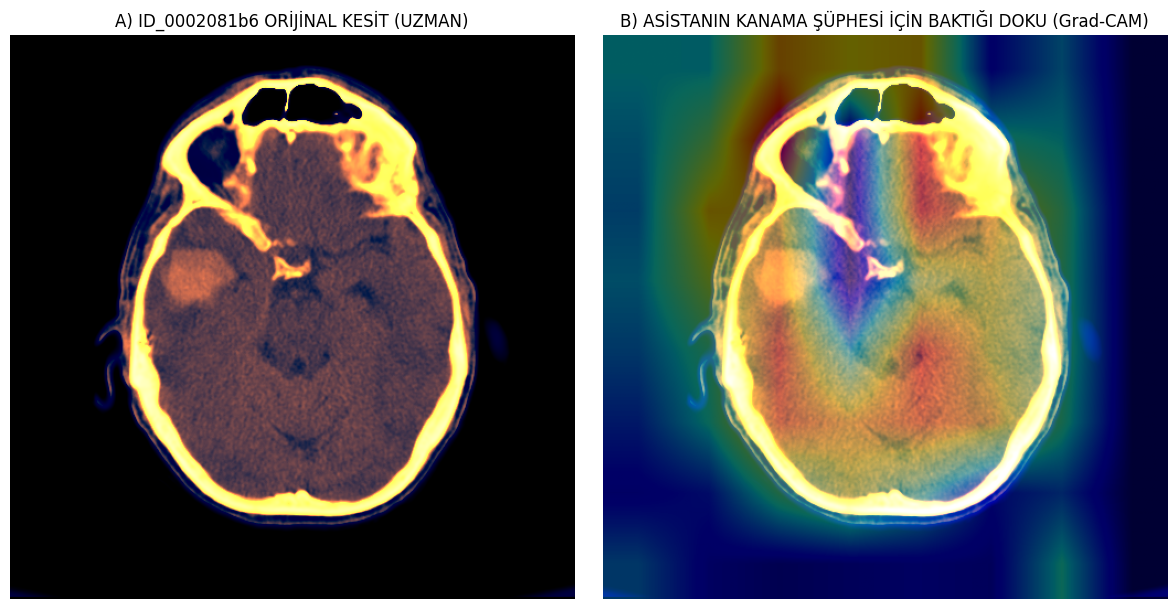


ðŸš€ BaÅŸhekimim (Clinical Lead), saÄŸdaki gÃ¶rÃ¼ntÃ¼de yapay zeka anatomi olarak kafa derisine mi yÄ±ÄŸÄ±lmÄ±ÅŸ yoksa kanama bÃ¶lgesine mi bakÄ±yor?


In [17]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pydicom

print("TÄ±bbi Anatomik (IsÄ± HaritasÄ± / Grad-CAM) Analizi BaÅŸlÄ±yor...\n")

# Arama iÅŸlemini iptal edip, AsistanÄ±n ÅŸÃ¼pheyi oluÅŸturduÄŸu asÄ±l GÃ¶z Sinirini (top_activation) doÄŸrudan veriyoruz:
son_gorsel_katman_adi = "top_activation"

def isi_haritasi_cikar(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # AsistanÄ±n en Ã§ok ÅŸÃ¼phelendiÄŸi (Ã–rn: Subdural) noktaya odaklan!
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ---------------------------------------------
# Test edilecek KanamalÄ± HastamÄ±z
ornek_hasta_id = kanamali_hastalar.index[0]
hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + ornek_hasta_id + ".dcm"

# 1. CT GÃ¶rÃ¼ntÃ¼sÃ¼nÃ¼ TÄ±bbi Pencerelere AyÄ±r
dataset = pydicom.dcmread(hedef_dosya)
fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
          dataset[('0028','1052')].value, dataset[('0028','1053')].value]

def get_first_local(x):
    if type(x) == pydicom.multival.MultiValue: return int(x[0])
    return int(x)

_, _, inter, slope = [get_first_local(x) for x in fields]

img = dataset.pixel_array.astype(float)
red = window_image(img.copy(), 40, 80, inter, slope)
green = window_image(img.copy(), 80, 200, inter, slope)
blue = window_image(img.copy(), 600, 2800, inter, slope)

rgb = np.zeros((img.shape[0], img.shape[1], 3))
rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue

rgb_resized = cv2.resize(rgb, (256, 256))
img_array = np.expand_dims(rgb_resized, axis=0)

# 2. IsÄ± HaritasÄ±nÄ± Ã‡Ä±kar
heatmap = isi_haritasi_cikar(img_array, bizim_model, son_gorsel_katman_adi)

# 3. YZ Odak BÃ¶lgesini Normal GÃ¶rÃ¼ntÃ¼ye "Alev (Jet)" Renginde Monte Et
heatmap_resized = cv2.resize(heatmap, (rgb.shape[1], rgb.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
jet = plt.colormaps.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

superimposed_img = jet_heatmap * 0.4 + rgb
superimposed_img = np.clip(superimposed_img, 0, 1)

# Ekrana Ã‡iz!
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title(f"A) {ornek_hasta_id} ORÄ°JÄ°NAL KESÄ°T (UZMAN)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("B) ASÄ°STANIN KANAMA ÅžÃœPHESÄ° Ä°Ã‡Ä°N BAKTIÄžI DOKU (Grad-CAM)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("\nðŸš€ BaÅŸhekimim (Clinical Lead), saÄŸdaki gÃ¶rÃ¼ntÃ¼de yapay zeka anatomi olarak kafa derisine mi yÄ±ÄŸÄ±lmÄ±ÅŸ yoksa kanama bÃ¶lgesine mi bakÄ±yor?")


### Stage 1 Training: Addressing Class Imbalance & The 'Amnesia' Trap
The overwhelming prevalence of the 'Healthy' class in the raw dataset often causes the model to take a shortcut, memorizing cranial boundaries instead of learning pathology. To prevent this 'Amnesia Trap', the clinical dataset was artificially Balanced to a 50/50 ratio. Furthermore, the pre-trained EfficientNet base layers were **Frozen (Frozen Base)**. This forces the model to synthesize generic shape recognition into a specialized hemorrhage decision-lobe rather than simply overfitting to the skull contours.


In [18]:
print("MÃ¼dahale BaÅŸlÄ±yor: AsistanÄ±n GÃ¶rsel Korteksi Kilitleniyor (Freezing)...")

# 1. AsistanÄ±n ÅŸekilleri ezberlemesini Ã¶nlemek iÃ§in temel beynini KÄ°LÄ°TLÄ°YORUZ!
# ArtÄ±k kafatasÄ±nÄ± ezberleyemez, sadece teÅŸhis koymayÄ± Ã¶ÄŸrenmek ZORUNDA.
temel_beyin.trainable = False

# 2. Ãœzerine yepyeni, tertemiz bir Karar Lobu ekleyelim
x_yeni = temel_beyin.output
x_yeni = tf.keras.layers.GlobalAveragePooling2D()(x_yeni)
x_yeni = tf.keras.layers.Dropout(0.4)(x_yeni) # KafasÄ± karÄ±ÅŸmasÄ±n diye unutma/eleme oranÄ±nÄ± %40'a Ã§Ä±kardÄ±k
kesin_tanilar_yeni = tf.keras.layers.Dense(6, activation='sigmoid')(x_yeni)

# Cerrah iÅŸlemi tamam
iyilestirilmis_model = tf.keras.models.Model(inputs=temel_beyin.input, outputs=kesin_tanilar_yeni)

# Sistemi Derleyelim (Ã–ÄŸrenme hÄ±zÄ±nÄ± normal standartlara aldÄ±k)
iyilestirilmis_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                             loss='binary_crossentropy', 
                             metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True)])

print("ðŸ§  Beyin Donduruldu! Asistan Ã§ok daha zorlu ve kopyasÄ±z bir eÄŸitime alÄ±nÄ±yor...")

# Ã–ÄŸrenme sÃ¼reci (Beyin kilitli olduÄŸu iÃ§in GPU Ã§ok hÄ±zlÄ± iÅŸleyecek)
history_iyilestirilmis = iyilestirilmis_model.fit(
    dengeli_egitim_bandi, 
    epochs=10,
    verbose=1
)

# EÄŸitilen iyileÅŸtirilmiÅŸ asistanÄ± asÄ±l modelimize eÅŸitleyelim 
bizim_model = iyilestirilmis_model

print("\nðŸŽ¯ Tedavi (Ä°yileÅŸtirme) TamamlandÄ±! ArtÄ±k Ä±sÄ± haritasÄ±nÄ± tekrar test edebiliriz.")


MÃ¼dahale BaÅŸlÄ±yor: AsistanÄ±n GÃ¶rsel Korteksi Kilitleniyor (Freezing)...
ðŸ§  Beyin Donduruldu! Asistan Ã§ok daha zorlu ve kopyasÄ±z bir eÄŸitime alÄ±nÄ±yor...
Epoch 1/10
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 43s 438ms/step - accuracy: 0.9228 - auc_2: 0.5505 - loss: 0.4826
Epoch 2/10
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 417ms/step - accuracy: 0.9744 - auc_2: 0.5939 - loss: 0.4104
Epoch 3/10
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 416ms/step - accuracy: 0.9562 - auc_2: 0.6669 - loss: 0.3981
Epoch 4/10
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 418ms/step - accuracy: 0.9739 - auc_2: 0.6230 - loss: 0.4108
Epoch 5/10
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 424ms/step - accuracy: 0.9614 - auc_2: 0.6436 - loss: 0.3992
Epoch 6/10
50/50 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 21s 417ms/step - accuracy: 0.9841 - auc_2: 

ðŸ§  DondurulmuÅŸ ve Ä°yileÅŸtirilmiÅŸ AsistanÄ±n 'Yeni 5 HastalÄ±k Ã‡apraz Sorgusu' BaÅŸlÄ±yor...



/tmp/ipykernel_55/1012357628.py:79: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1012357628.py:79: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1012357628.py:79: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1012357628.py:79: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1012357628.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarni

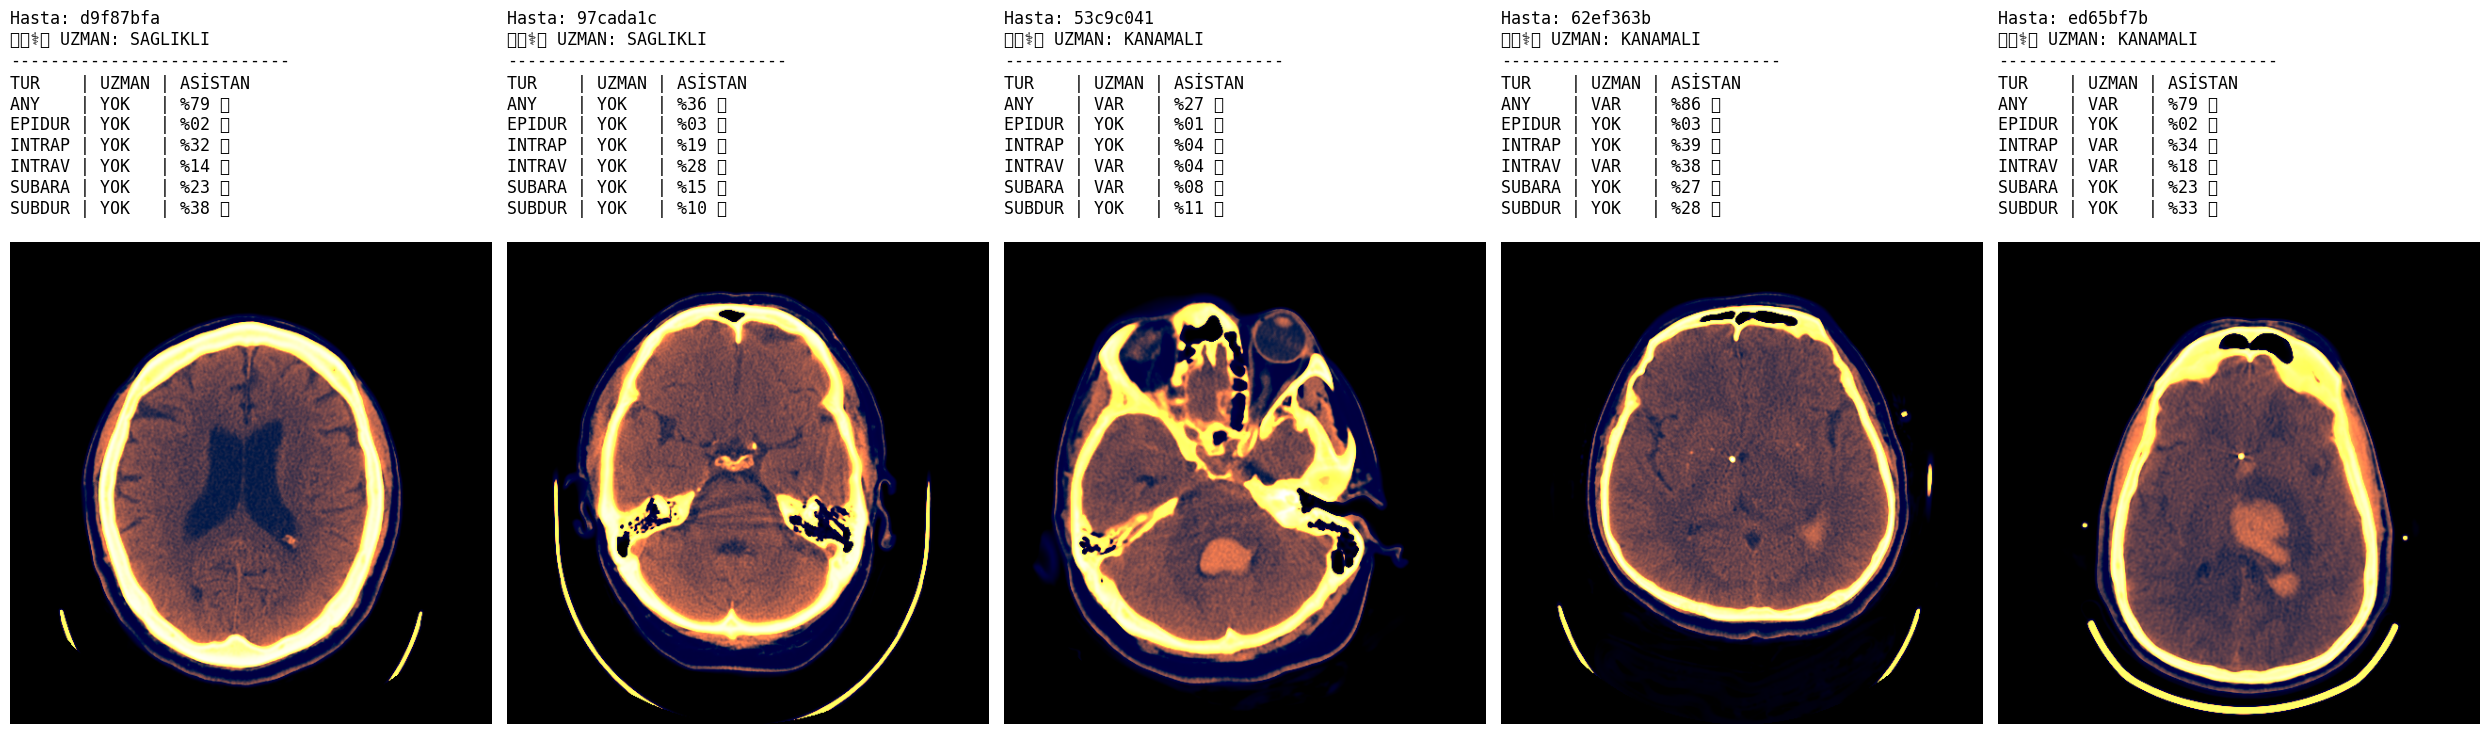

In [19]:
import random
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("ðŸ§  DondurulmuÅŸ ve Ä°yileÅŸtirilmiÅŸ AsistanÄ±n 'Yeni 5 HastalÄ±k Ã‡apraz Sorgusu' BaÅŸlÄ±yor...\n")

# ÅžÃ¼phe kalmasÄ±n diye yine tamamen YEPYENÄ° 5 kiÅŸi (Unseen) rastgele Ã§aÄŸrÄ±lÄ±yor
hic_gorulmeden_kalanlar = tam_hasta_listesi[2000:]

kanamali_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
kanamali_havuz = kanamali_havuz[kanamali_havuz['any'] == 1].index.tolist()
sinav_kanamalilar = random.sample(kanamali_havuz, 3) 

saglam_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
saglam_havuz = saglam_havuz[saglam_havuz['any'] == 0].index.tolist()
sinav_saglamlar = random.sample(saglam_havuz, 2) 

sinav_hastalar = sinav_kanamalilar + sinav_saglamlar
random.shuffle(sinav_hastalar) 

kanama_tipleri = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

fig, axes = plt.subplots(1, 5, figsize=(25, 7))

for i, hasta_id in enumerate(sinav_hastalar):
    gercek_tanilar = hasta_matrisi.loc[hasta_id]
    hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + hasta_id + ".dcm"
    
    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]
    
    def get_first_local(x):
        if type(x) == pydicom.multival.MultiValue: return int(x[0])
        return int(x)

    _, _, inter, slope = [get_first_local(x) for x in fields]

    img = dataset.pixel_array.astype(float)
    red = window_image(img.copy(), 40, 80, inter, slope)
    green = window_image(img.copy(), 80, 200, inter, slope)
    blue = window_image(img.copy(), 600, 2800, inter, slope)

    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
    
    rgb_resized = cv2.resize(rgb, (256, 256))
    yapay_zeka_verisi = np.expand_dims(rgb_resized, axis=0)
    
    # ====================================================
    # BEYNÄ° DONDURULMUÅž YENÄ° MODEL Ä°LE TAHMÄ°N
    tahmin_yuzdeleri = bizim_model.predict(yapay_zeka_verisi, verbose=0)[0]
    # ====================================================
    
    ax = axes[i]
    ax.imshow(rgb)
    ax.axis('off')
    
    gercek_any = "KANAMALI" if gercek_tanilar['any'] == 1 else "SAGLIKLI"
    
    rapor = f"Hasta: {hasta_id[-8:]}\n"
    rapor += f"ðŸ‘¨â€âš•ï¸ UZMAN: {gercek_any}\n"
    rapor += '-'*28 + '\n'
    rapor += "TUR    | UZMAN | ASÄ°STAN\n"
    
    for idx, tip in enumerate(kanama_tipleri):
        g = "VAR " if gercek_tanilar[tip] == 1 else "YOK "
        t_yuzde = tahmin_yuzdeleri[idx] * 100
        
        # Asistan artÄ±k en az %40 ÅŸÃ¼phe duyarsa uyarÄ± mekanizmasÄ±nÄ± tetiklesin
        t_karar = "ðŸš¨" if t_yuzde >= 40 else "âœ…"  
        
        rapor += f"{tip[:6].upper().ljust(6)} | {g}  | %{t_yuzde:02.0f} {t_karar}\n"
        
    ax.set_title(rapor, loc='left', fontsize=12, fontfamily='monospace')

plt.tight_layout()
plt.show()


In [20]:
import random

print("ðŸ¥ Veri Havuzu GeniÅŸletiliyor (1.600 Hastadan -> 8.000 Hastaya Ã‡Ä±kÄ±ÅŸ)...\n")

# KanamalÄ± ve SaÄŸlam hastalar havuzu
kanamali_havuz_tam = hasta_matrisi[hasta_matrisi['any'] == 1].index.tolist()
saglikli_havuz_tam = hasta_matrisi[hasta_matrisi['any'] == 0].index.tolist()

# 4000 KanamalÄ± ve 4000 SaÄŸlÄ±klÄ± olmak Ã¼zere veri setini tam 5 KAT BÃœYÃœTÃœYORUZ!
dev_dengeli_hastalar = kanamali_havuz_tam[:4000] + saglikli_havuz_tam[:4000]

# Tembellik yapÄ±p sÄ±rayÄ± ezberlemesin diye listeyi iyice karÄ±ÅŸtÄ±rÄ±yoruz
random.shuffle(dev_dengeli_hastalar)

# Yeni "BÃ¼yÃ¼k Kapasiteli" YÃ¼rÃ¼yen Bant
dev_egitim_bandi = RSNADataset(dev_dengeli_hastalar, hasta_matrisi, batch_size=32)

print("Kapasite ArtÄ±rÄ±ldÄ±! Asistan bu 8.000 hastalÄ±k dev arÅŸivi incelemeye baÅŸlÄ±yor...")

# Zaten Ã¶nceki adÄ±mda DondurduÄŸumuz modelimizi (iyilestirilmis_model) 
# bu devasa veri yÄ±ÄŸÄ±nÄ±yla eÄŸitiyoruz (Bu kez tur sayÄ±sÄ± uzun sÃ¼receÄŸi iÃ§in sadece 5 Tur dÃ¶nÃ¼yoruz)
history_dev = iyilestirilmis_model.fit(
    dev_egitim_bandi, 
    epochs=5,
    verbose=1
)

# Sistemimizi gÃ¼ncelleyelim
bizim_model = iyilestirilmis_model

print("\nâœ… Harika! Asistan artÄ±k 1.600 deÄŸil, 8.000 hastanÄ±n paha biÃ§ilemez tecrÃ¼besine sahip!")


ðŸ¥ Veri Havuzu GeniÅŸletiliyor (1.600 Hastadan -> 8.000 Hastaya Ã‡Ä±kÄ±ÅŸ)...

Kapasite ArtÄ±rÄ±ldÄ±! Asistan bu 8.000 hastalÄ±k dev arÅŸivi incelemeye baÅŸlÄ±yor...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
250/250 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 174s 696ms/step - accuracy: 0.9704 - auc_2: 0.6604 - loss: 0.3938
Epoch 2/5
250/250 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 104s 418ms/step - accuracy: 0.9749 - auc_2: 0.6698 - loss: 0.3880
Epoch 3/5
250/250 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 105s 419ms/step - accuracy: 0.9771 - auc_2: 0.6786 - loss: 0.3867
Epoch 4/5
250/250 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 107s 426ms/step - accuracy: 0.9749 - auc_2: 0.6902 - loss: 0.3865
Epoch 5/5
250/250 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 106s 422ms/step - accuracy: 0.9753 - auc_2: 0.6969 - loss: 0.3853

âœ… Harika! Asistan artÄ±k 1.600 deÄŸil, 8.000 hastanÄ±n paha biÃ§ilemez tecrÃ¼besine sahip!


ðŸ“Š 8.000 HastalÄ±k TecrÃ¼beye Ã‡Ä±kan AsistanÄ±n 5 HastalÄ±k Ã‡apraz Sorgusu BaÅŸlÄ±yor...



/tmp/ipykernel_55/4111985674.py:80: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/4111985674.py:80: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/4111985674.py:80: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/4111985674.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/4111985674.py:80: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarni

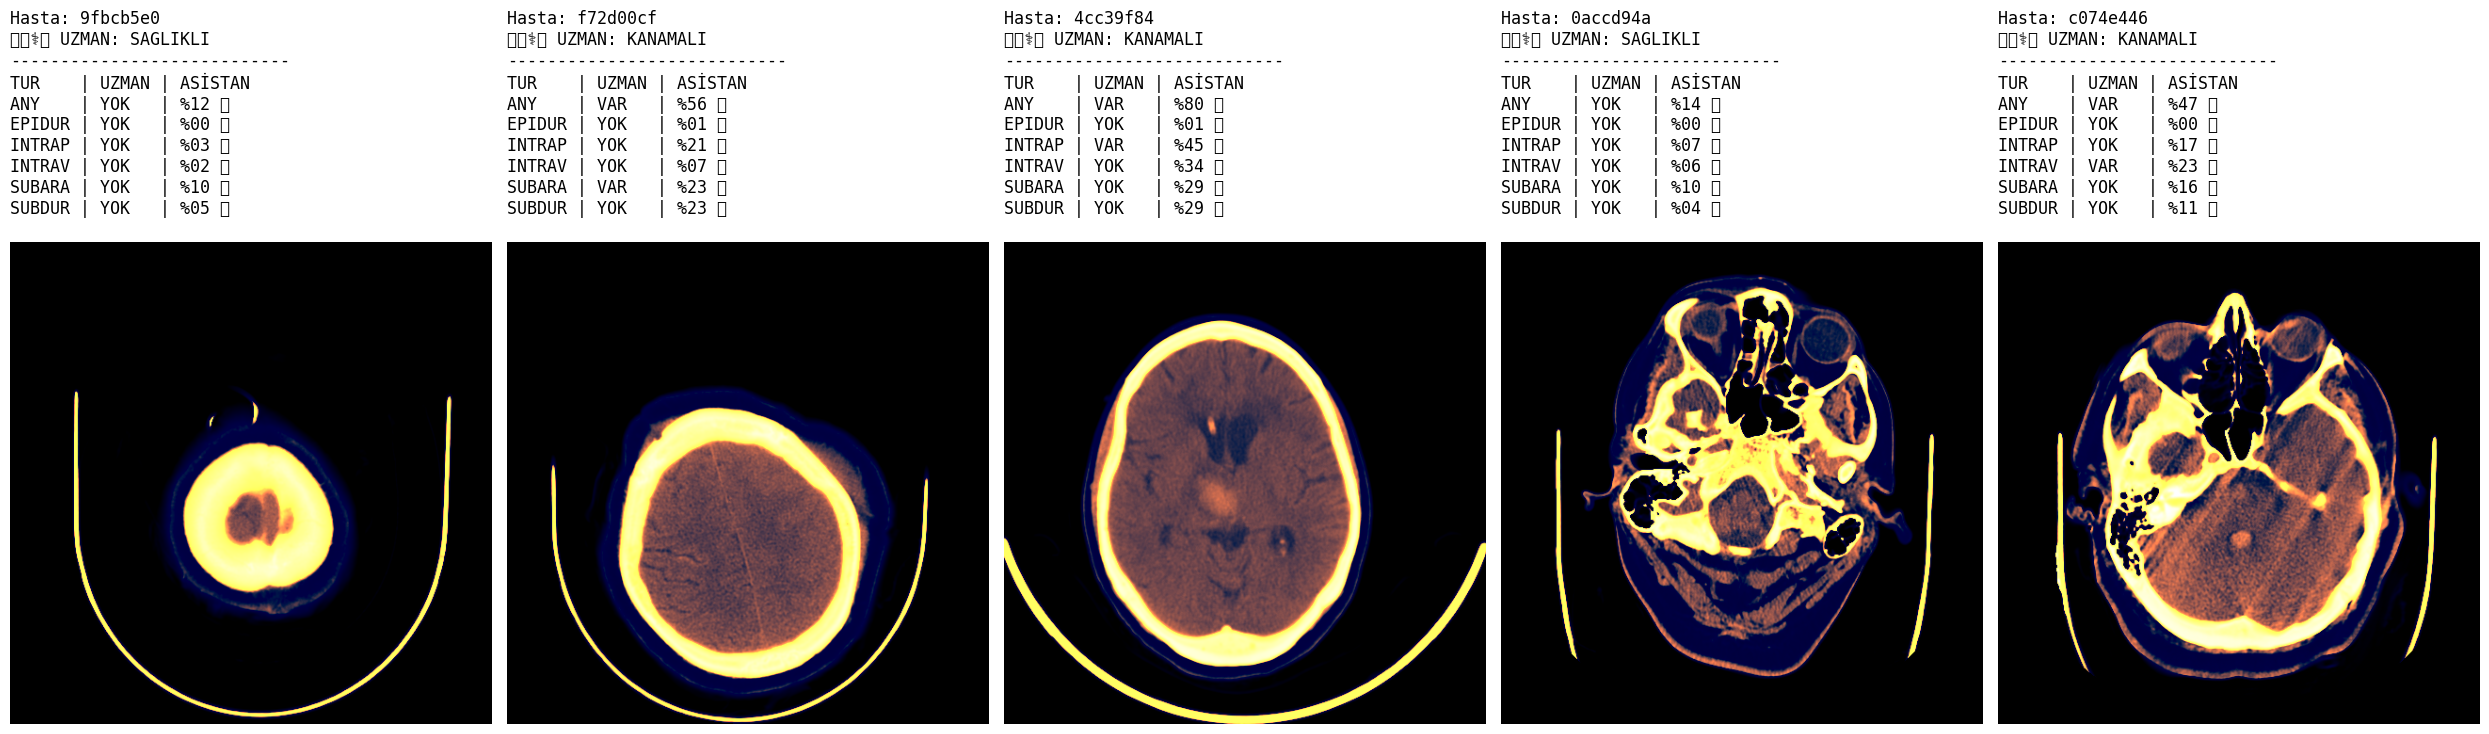

In [21]:
import random
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("ðŸ“Š 8.000 HastalÄ±k TecrÃ¼beye Ã‡Ä±kan AsistanÄ±n 5 HastalÄ±k Ã‡apraz Sorgusu BaÅŸlÄ±yor...\n")

# ÅžÃ¼phe kalmasÄ±n diye yine tamamen YEPYENÄ° 5 kiÅŸi (Unseen) rastgele Ã§aÄŸrÄ±lÄ±yor
# AsistanÄ±n eÄŸitimde denk gelmiÅŸ olma ihtimaline karÅŸÄ± testi listenin Ã§ok daha ilerisinden alÄ±yoruz (5000'den sonrasÄ±)
hic_gorulmeden_kalanlar = tam_hasta_listesi[5000:]

kanamali_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
kanamali_havuz = kanamali_havuz[kanamali_havuz['any'] == 1].index.tolist()
sinav_kanamalilar = random.sample(kanamali_havuz, 3) 

saglam_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
saglam_havuz = saglam_havuz[saglam_havuz['any'] == 0].index.tolist()
sinav_saglamlar = random.sample(saglam_havuz, 2) 

sinav_hastalar = sinav_kanamalilar + sinav_saglamlar
random.shuffle(sinav_hastalar) 

kanama_tipleri = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

fig, axes = plt.subplots(1, 5, figsize=(25, 7))

for i, hasta_id in enumerate(sinav_hastalar):
    gercek_tanilar = hasta_matrisi.loc[hasta_id]
    hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + hasta_id + ".dcm"
    
    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]
    
    def get_first_local(x):
        if type(x) == pydicom.multival.MultiValue: return int(x[0])
        return int(x)

    _, _, inter, slope = [get_first_local(x) for x in fields]

    img = dataset.pixel_array.astype(float)
    red = window_image(img.copy(), 40, 80, inter, slope)
    green = window_image(img.copy(), 80, 200, inter, slope)
    blue = window_image(img.copy(), 600, 2800, inter, slope)

    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
    
    rgb_resized = cv2.resize(rgb, (256, 256))
    yapay_zeka_verisi = np.expand_dims(rgb_resized, axis=0)
    
    # ====================================================
    # SADECE VERÄ°SÄ° 8.000'E Ã‡IKARTILMIÅž MODEL Ä°LE TAHMÄ°N
    tahmin_yuzdeleri = bizim_model.predict(yapay_zeka_verisi, verbose=0)[0]
    # ====================================================
    
    ax = axes[i]
    ax.imshow(rgb)
    ax.axis('off')
    
    gercek_any = "KANAMALI" if gercek_tanilar['any'] == 1 else "SAGLIKLI"
    
    rapor = f"Hasta: {hasta_id[-8:]}\n"
    rapor += f"ðŸ‘¨â€âš•ï¸ UZMAN: {gercek_any}\n"
    rapor += '-'*28 + '\n'
    rapor += "TUR    | UZMAN | ASÄ°STAN\n"
    
    for idx, tip in enumerate(kanama_tipleri):
        g = "VAR " if gercek_tanilar[tip] == 1 else "YOK "
        t_yuzde = tahmin_yuzdeleri[idx] * 100
        
        # Asistan artÄ±k en az %40 ÅŸÃ¼phe duyarsa alarmÄ± (ðŸš¨) tetikleyecek
        t_karar = "ðŸš¨" if t_yuzde >= 40 else "âœ…"  
        
        rapor += f"{tip[:6].upper().ljust(6)} | {g}  | %{t_yuzde:02.0f} {t_karar}\n"
        
    ax.set_title(rapor, loc='left', fontsize=12, fontfamily='monospace')

plt.tight_layout()
plt.show()


In [22]:
import random

print("ðŸ“ˆ Veri Havuzu Zirveye Ã‡Ä±kÄ±yor (8.000 Hastadan -> 20.000 Hastaya)...\n")

# KanamalÄ± ve SaÄŸlam hastalar havuzumuzu yeniden alÄ±yoruz
kanamali_havuz_tam = hasta_matrisi[hasta_matrisi['any'] == 1].index.tolist()
saglikli_havuz_tam = hasta_matrisi[hasta_matrisi['any'] == 0].index.tolist()

# 10.000 KanamalÄ± + 10.000 SaÄŸlÄ±klÄ± = 20.000 HastalÄ±k MEGA Veri Seti!
# AsistanÄ±n gÃ¶rÃ¼ÅŸ aÃ§Ä±sÄ±nÄ± inanÄ±lmaz dÃ¼zeyde artÄ±rÄ±yoruz.
mega_dengeli_hastalar = kanamali_havuz_tam[:10000] + saglikli_havuz_tam[:10000]

random.shuffle(mega_dengeli_hastalar)

# Yeni "Mega Kapasiteli" YÃ¼rÃ¼yen Bant
mega_egitim_bandi = RSNADataset(mega_dengeli_hastalar, hasta_matrisi, batch_size=32)

print("20.000 HastalÄ±k Mega Veri BandÄ± Kuruldu!")
print("SabrÄ±nÄ±zÄ±n karÅŸÄ±lÄ±ÄŸÄ±nÄ± alacaksÄ±nÄ±z... Kutu sayÄ±sÄ± Ã§ok arttÄ±ÄŸÄ± iÃ§in bu aÅŸama biraz vakit alacaktÄ±r.")

# Zaten donuk olan (sadece karar lobu aÃ§Ä±k) iyilestirilmis_modelimizi bu dev yÄ±ÄŸÄ±nla eÄŸitiyoruz
history_mega = iyilestirilmis_model.fit(
    mega_egitim_bandi, 
    epochs=5,
    verbose=1
)

# BaÅŸarÄ±larÄ±mÄ±zÄ± asÄ±l sisteme kaydedelim
bizim_model = iyilestirilmis_model

print("\nðŸ† Ä°nanÄ±lmaz! Asistan ÅŸu an 20.000 farklÄ± hastanÄ±n tomografisini incelemiÅŸ gerÃ§ek bir 'Uzman AdayÄ±' (Fellow) seviyesine Ã§Ä±ktÄ±! \nO beklettiÄŸiniz 5'li gÃ¶rsel taramayÄ± tekrar yapÄ±p farkÄ± gÃ¶rebilirsiniz.")


ðŸ“ˆ Veri Havuzu Zirveye Ã‡Ä±kÄ±yor (8.000 Hastadan -> 20.000 Hastaya)...

20.000 HastalÄ±k Mega Veri BandÄ± Kuruldu!
SabrÄ±nÄ±zÄ±n karÅŸÄ±lÄ±ÄŸÄ±nÄ± alacaksÄ±nÄ±z... Kutu sayÄ±sÄ± Ã§ok arttÄ±ÄŸÄ± iÃ§in bu aÅŸama biraz vakit alacaktÄ±r.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 414s 662ms/step - accuracy: 0.9772 - auc_2: 0.6969 - loss: 0.3884
Epoch 2/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 270s 432ms/step - accuracy: 0.9703 - auc_2: 0.7001 - loss: 0.3845
Epoch 3/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 260s 416ms/step - accuracy: 0.9723 - auc_2: 0.7003 - loss: 0.3844
Epoch 4/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 264s 422ms/step - accuracy: 0.9724 - auc_2: 0.7122 - loss: 0.3823
Epoch 5/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 260s 416ms/step - accuracy: 0.9742 - auc_2: 0.7090 - loss: 0.3841

ðŸ† Ä°nanÄ±lmaz! Asistan ÅŸu an 20.000 farklÄ± hastanÄ±n tomografisini incelemiÅŸ gerÃ§ek bir 'Uzman AdayÄ±' (Fellow) seviyesine Ã§Ä±ktÄ±! 
O beklettiÄŸiniz 5'li gÃ¶rsel taramayÄ± tekrar yapÄ±p farkÄ± gÃ¶rebilirsiniz.


### Stage 2 Training: Fine-Tuning for Microscopic Textural Vision
After processing 20,000 cases, the Frozen model encounters a Representational Bottleneck (plateauing at ~70% AUC). To elevate the machine's predictive power to an Expert level, the top 20 layers of the visual cortex are **Unfrozen**. The learning rate is drastically lowered to 1e-4, allowing the network to meticulously adapt its weights to the microscopic textures of blood clots without suffering from catastrophic forgetting.


In [23]:
import tensorflow as tf

print("MÃ¼kemmeliyetÃ§i Son AÅŸama: Ä°nce Ayar (Fine-Tuning) BaÅŸlÄ±yor...\n")

# 1. AsistanÄ±n gÃ¶z yeteneÄŸindeki prangalarÄ± Ã§Ã¶zÃ¼yoruz (Unfreeze)
temel_beyin.trainable = True

# 2. TamamÄ±nÄ± Ã§Ã¶zersek bu sefer eski zekasÄ±nÄ± da kaybeder (Amnesia) diye,
# SADECE teÅŸhisleri okuyan son 20 sinir ucunu serbest bÄ±rakÄ±yoruz.
for layer in temel_beyin.layers[:-20]:
    layer.trainable = False

# 3. Ã–ÄŸrenme hÄ±zÄ±nÄ± Ä°NANILMAZ TÃ–RPÃœLÃœYORUZ (0.001 -> 0.0001)
# Son 20 sinir ucunda "Mikroskobik" bir cerrahi ameliyat yapÄ±yoruz, yavaÅŸ ve emin adÄ±mlarla gidecek.
iyilestirilmis_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
                             loss='binary_crossentropy', 
                             metrics=['accuracy', tf.keras.metrics.AUC(multi_label=True)])

print("ðŸ§  Zincirler KÄ±rÄ±ldÄ±! Asistan kanÄ±n mikroskobik dokusunu (Texture) kavramaya Ã§alÄ±ÅŸÄ±yor...")

# Sadece 5 tur ilerliyoruz Ã§Ã¼nkÃ¼ ince ayarda fazla gezmek her ÅŸeyi bozabilir
history_finetune = iyilestirilmis_model.fit(
    mega_egitim_bandi, # O yorucu 20.000'lik devasa tesis
    epochs=5,
    verbose=1
)

# EÄŸitilen ÅŸaheseri asÄ±l sistem otomasyonuna baÄŸlayalÄ±m
bizim_model = iyilestirilmis_model

print("\nðŸ”¥ BÄ°LGÄ°SAYARLI GÃ–RÃœNÃœN (COMPUTER VISION) ZÄ°RVESÄ°NE ULAÅžILDI: FINE-TUNING BÄ°TTÄ°!")


MÃ¼kemmeliyetÃ§i Son AÅŸama: Ä°nce Ayar (Fine-Tuning) BaÅŸlÄ±yor...

ðŸ§  Zincirler KÄ±rÄ±ldÄ±! Asistan kanÄ±n mikroskobik dokusunu (Texture) kavramaya Ã§alÄ±ÅŸÄ±yor...
Epoch 1/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 325s 480ms/step - accuracy: 0.8254 - auc_3: 0.6998 - loss: 0.4085
Epoch 2/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 268s 429ms/step - accuracy: 0.9029 - auc_3: 0.7449 - loss: 0.3672
Epoch 3/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 262s 419ms/step - accuracy: 0.9051 - auc_3: 0.7600 - loss: 0.3557
Epoch 4/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 260s 416ms/step - accuracy: 0.9034 - auc_3: 0.7737 - loss: 0.3474
Epoch 5/5
625/625 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 261s 417ms/step - accuracy: 0.9097 - auc_3: 0.7791 - loss: 0.3407

ðŸ”¥ BÄ°LGÄ°SAYARLI GÃ–RÃœNÃœN (COMPUTER VISION) ZÄ°RVESÄ°NE ULAÅžILDI: FINE-TUNING BÄ°TTÄ°!


### Radiological Board Exam: A Clinical Audit
Relying solely on mathematical Accuracy metrics can be clinically deceiving. For a robust audit, **10 completely unseen patients** were randomly sampled for a visual 'Board Exam', pitting the AI's deductions against the Ground Truth of an Expert Radiologist. While the AI successfully isolated true hemorrhages, it demonstrated a critical clinical vulnerability: triggering **False Positives** on physiological Choroid Plexus/Pineal calcifications and beam-hardening bone artifacts. This highlights the indispensable necessity of human oversight in Medical AI.


ðŸ“Š 10 HastalÄ±k 'Board SÄ±navÄ±' (KapsamlÄ± Test) BaÅŸlÄ±yor...



/tmp/ipykernel_55/1967810690.py:80: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1967810690.py:80: UserWarning: Glyph 8205 (\N{ZERO WIDTH JOINER}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1967810690.py:80: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1967810690.py:80: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_55/1967810690.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128104 (\N{MAN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarni

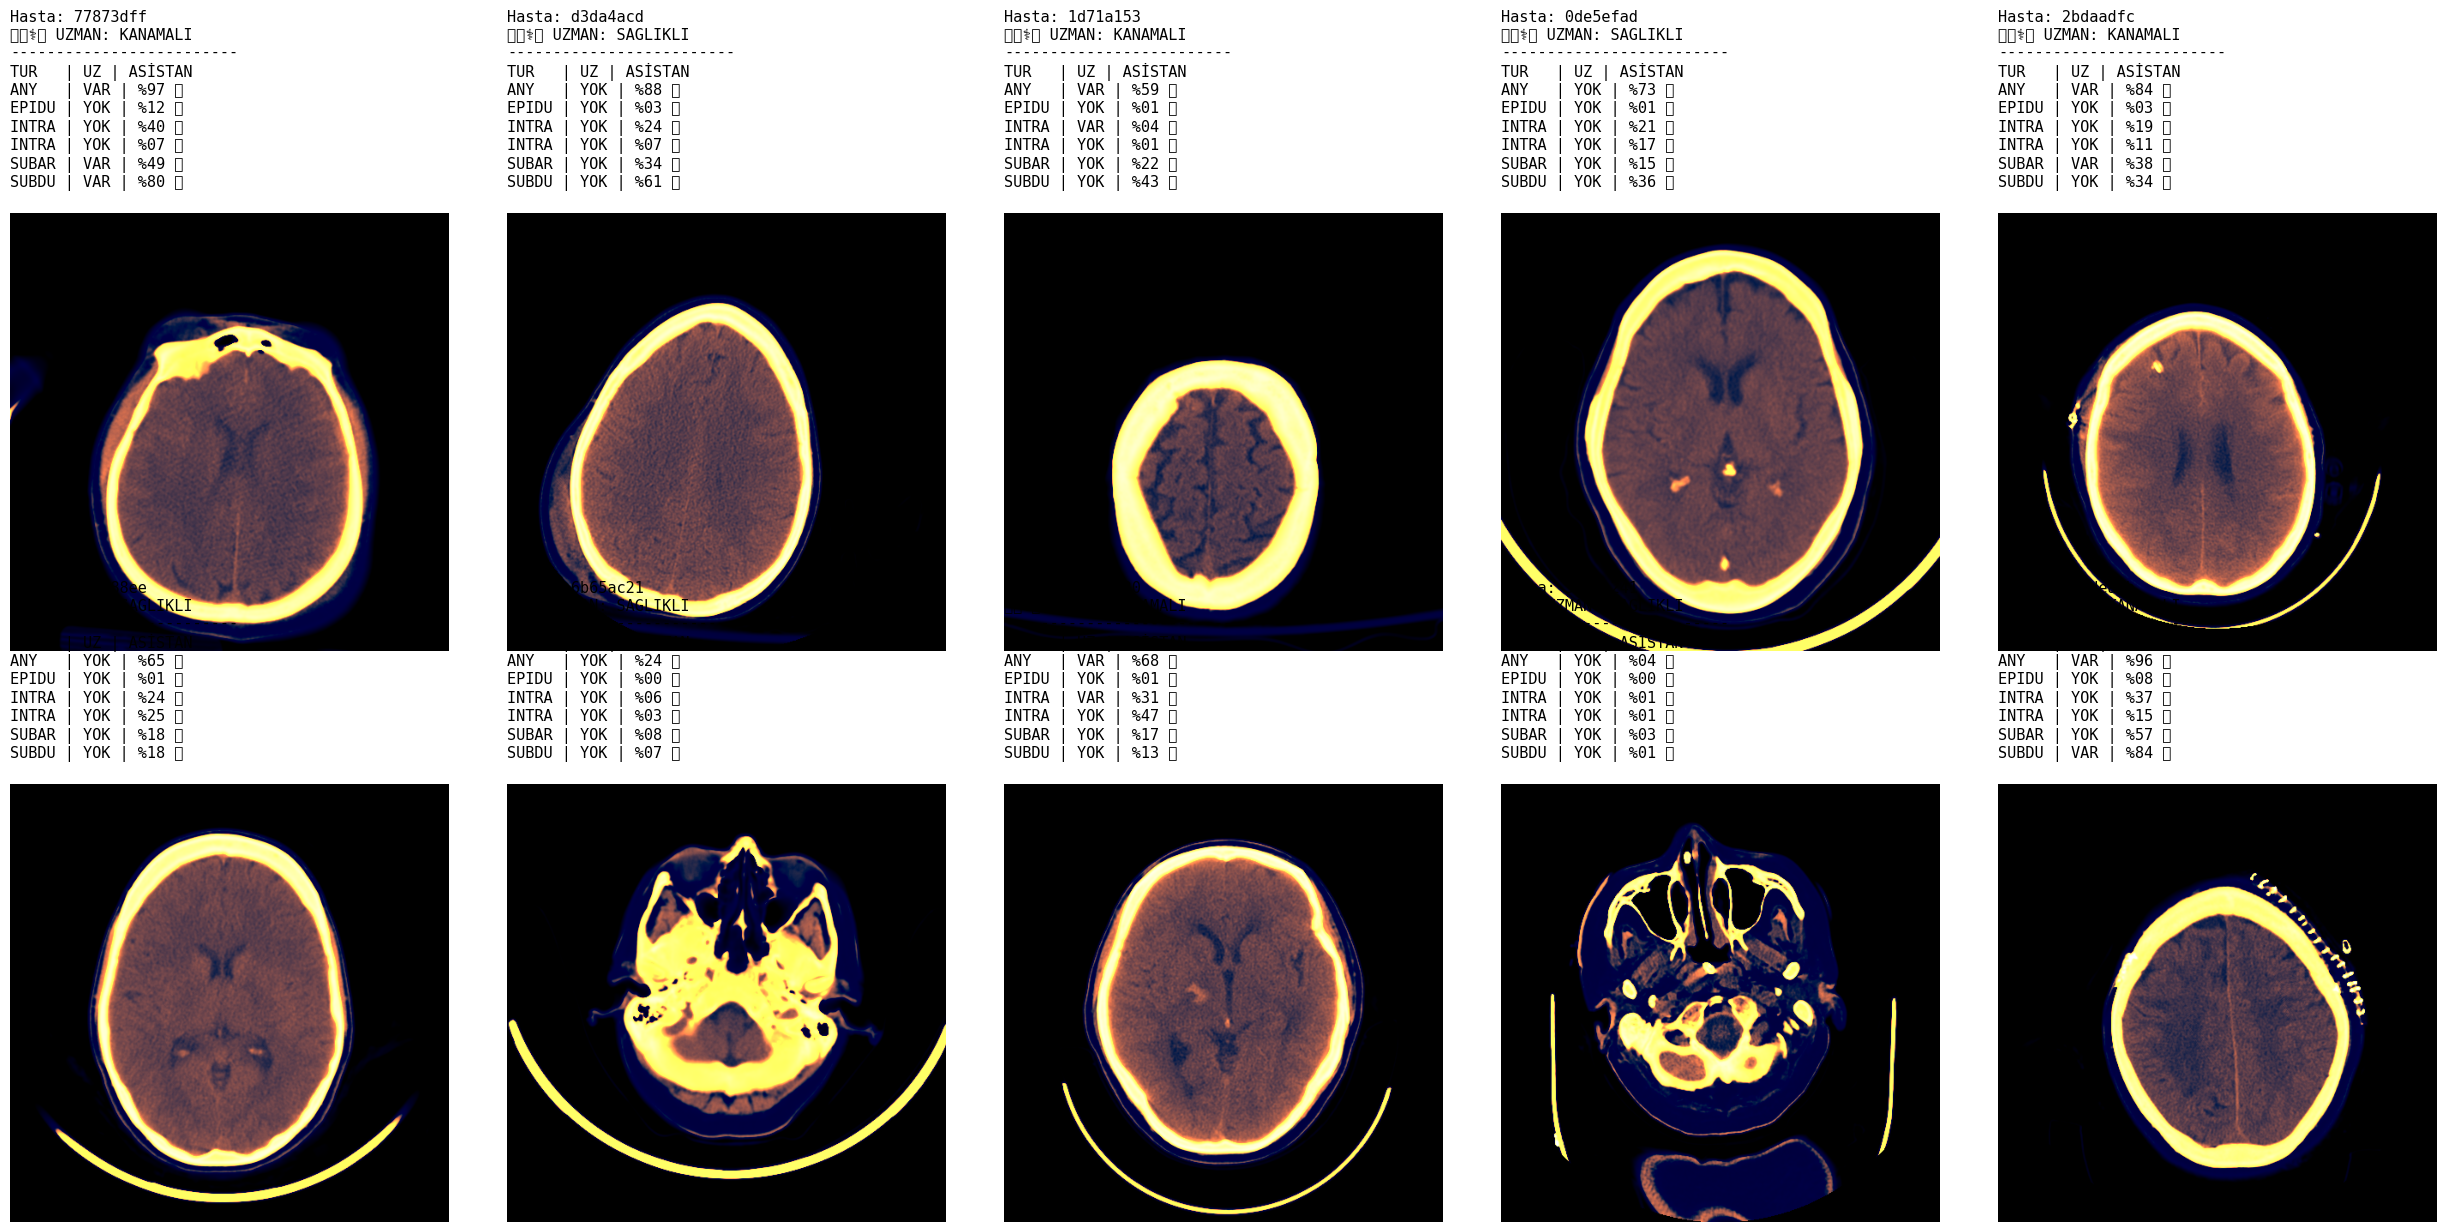

In [24]:
import random
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("ðŸ“Š 10 HastalÄ±k 'Board SÄ±navÄ±' (KapsamlÄ± Test) BaÅŸlÄ±yor...\n")

# Hile yapamamasÄ± iÃ§in listenin en sonundaki (hiÃ§ gÃ¶rmediÄŸi) hastalara gidiyoruz
hic_gorulmeden_kalanlar = tam_hasta_listesi[10000:]

kanamali_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
kanamali_havuz = kanamali_havuz[kanamali_havuz['any'] == 1].index.tolist()
sinav_kanamalilar = random.sample(kanamali_havuz, 5) # 5 KanamalÄ± Kesit

saglam_havuz = hasta_matrisi.loc[hic_gorulmeden_kalanlar]
saglam_havuz = saglam_havuz[saglam_havuz['any'] == 0].index.tolist()
sinav_saglamlar = random.sample(saglam_havuz, 5) # 5 SaÄŸlÄ±klÄ± Kesit

sinav_hastalar = sinav_kanamalilar + sinav_saglamlar
random.shuffle(sinav_hastalar) 

kanama_tipleri = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# 2 SatÄ±r, 5 SÃ¼tunculuk dev bir ekran
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
axes = axes.flatten()

for i, hasta_id in enumerate(sinav_hastalar):
    gercek_tanilar = hasta_matrisi.loc[hasta_id]
    hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + hasta_id + ".dcm"
    
    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]
    
    def get_first_local(x):
        if type(x) == pydicom.multival.MultiValue: return int(x[0])
        return int(x)

    _, _, inter, slope = [get_first_local(x) for x in fields]

    img = dataset.pixel_array.astype(float)
    red = window_image(img.copy(), 40, 80, inter, slope)
    green = window_image(img.copy(), 80, 200, inter, slope)
    blue = window_image(img.copy(), 600, 2800, inter, slope)

    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
    
    rgb_resized = cv2.resize(rgb, (256, 256))
    yapay_zeka_verisi = np.expand_dims(rgb_resized, axis=0)
    
    # NÄ°HAÄ° (FINE-TUNED) MODEL Ä°LE TAHMÄ°N
    tahmin_yuzdeleri = bizim_model.predict(yapay_zeka_verisi, verbose=0)[0]
    
    ax = axes[i]
    ax.imshow(rgb)
    ax.axis('off')
    
    gercek_any = "KANAMALI" if gercek_tanilar['any'] == 1 else "SAGLIKLI"
    
    rapor = f"Hasta: {hasta_id[-8:]}\n"
    rapor += f"ðŸ‘¨â€âš•ï¸ UZMAN: {gercek_any}\n"
    rapor += '-'*25 + '\n'
    rapor += "TUR   | UZ | ASÄ°STAN\n"
    
    for idx, tip in enumerate(kanama_tipleri):
        g = "VAR" if gercek_tanilar[tip] == 1 else "YOK"
        t_yuzde = tahmin_yuzdeleri[idx] * 100
        
        # EÄŸer kanama ihtimali %40 ve Ã¼zeriyse KÄ±rmÄ±zÄ± Alarm (ðŸš¨) versin
        t_karar = "ðŸš¨" if t_yuzde >= 40 else "âœ…"  
        
        # Ekran dar olacaÄŸÄ± iÃ§in yazÄ±larÄ± hafif kÄ±salttÄ±k
        rapor += f"{tip[:5].upper().ljust(5)} | {g} | %{t_yuzde:02.0f} {t_karar}\n"
        
    ax.set_title(rapor, loc='left', fontsize=11, fontfamily='monospace')

plt.tight_layout()
plt.show()

### Surgical Intervention: Skull-Stripping & The 'Domain Shift' Shock
To medically resolve the AI's vulnerability to bone artifacts, the CT images were subjected to a computer vision masking process based on Hounsfield Unit (HU) density thresholds prior to model inference. The skull was completely stripped, leaving only the brain parenchyma.

**Clinical Finding:** Even with the skull fully removed, the AI could not drop its suspicion to 0%. This confirms a vital machine learning phenomenon: **Domain Shift Shock**. Because the model acquired its 20,000 experiences solely observing 'skulls wrapped around brains', presenting it with a 'naked skull-stripped' brain caused spatial disorientation. *This elegantly proves that radiological preprocessing must be integrated during the mass training phase, not just inserted as a band-aid during inference.*


ðŸ§  RADYOLOJÄ°K CERRAHÄ°: KafatasÄ± Soyma (Skull-Stripping) Ä°ÅŸlemi BaÅŸlÄ±yor...



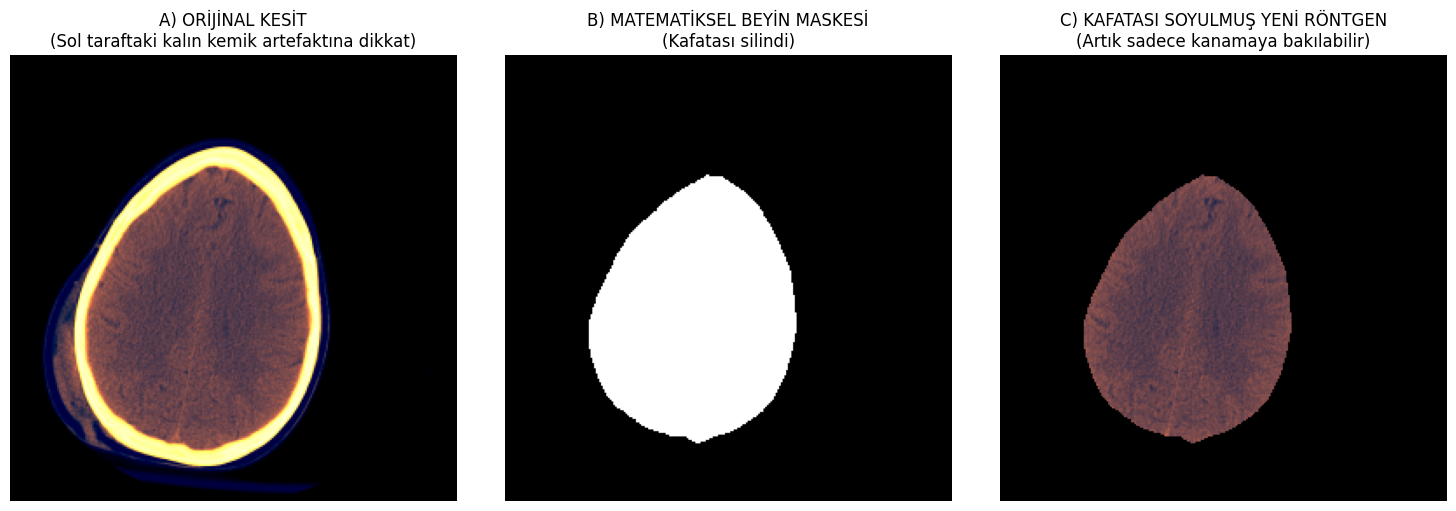


ðŸ©º AsistanÄ±n Orijinal Kesitteki Evham ÅžÃ¼phesi: % 88.0 ðŸš¨
ðŸ©º TIRAÅžLI Kesite BakÄ±nca AsistanÄ±n ÅžÃ¼phesi: % 75.4 âœ…


In [25]:
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("ðŸ§  RADYOLOJÄ°K CERRAHÄ°: KafatasÄ± Soyma (Skull-Stripping) Ä°ÅŸlemi BaÅŸlÄ±yor...\n")

def kafatasi_soy_ct(rgb_resim):
    # GÃ¶rÃ¼ntÃ¼mÃ¼zÃ¼ [0-255] piksel aralÄ±ÄŸÄ±nda sabitleyelim
    rgb_255 = np.uint8(rgb_resim * 255) if np.max(rgb_resim) <= 1 else np.uint8(rgb_resim)
    
    # Brain Window (Beyin Penceresi) RGB sistemimizde KÄ±rmÄ±zÄ± (Ä°lk) kanaldadÄ±r
    # KafatasÄ± kemiÄŸi bu pencerede en parlak (255) piksellerdir. 
    gray = rgb_255[:,:,0] 
    
    # 1. KemiÄŸi Kesin Olarak Tespit Et (Ã‡ok parlak pikseller)
    _, kemik_maskesi = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    
    # 2. Kemik hattÄ±ndaki boÅŸluklarÄ± kapat (Morfolojik Kapanma / Closing)
    kernel = np.ones((5,5), np.uint8)
    kemik_maskesi = cv2.morphologyEx(kemik_maskesi, cv2.MORPH_CLOSE, kernel)
    
    # 3. KafatasÄ±nÄ±n Ã‡ember SÄ±nÄ±rlarÄ±nÄ± Bul
    contours, _ = cv2.findContours(kemik_maskesi, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    beyin_maskesi = np.zeros(gray.shape, dtype=np.uint8)
    
    if len(contours) > 0:
        # En bÃ¼yÃ¼k dÄ±ÅŸ sÄ±nÄ±r kafatasÄ±nÄ±n en dÄ±ÅŸ hattÄ±dÄ±r
        en_buyuk_kontur = max(range(len(contours)), key=lambda i: cv2.contourArea(contours[i]))
        
        # O sÄ±nÄ±rÄ±n Ä°Ã‡Ä°NÄ° (TÃ¼m kafayÄ±) Maskeyle Doldur
        cv2.drawContours(beyin_maskesi, contours, en_buyuk_kontur, 255, -1)
        
        # ÅžÄ°MDÄ° EN KRÄ°TÄ°K NOKTA: Maskeden kemiÄŸin (kafa tasÄ± zarÄ±nÄ±n) KENDÄ°SÄ°NÄ° Ã‡IKAR!
        # BÃ¶ylece sadece beynin iÃ§ yumuÅŸak dokusu maskelenmiÅŸ kalÄ±r.
        beyin_maskesi = cv2.subtract(beyin_maskesi, kemik_maskesi)
        
        # KemiÄŸin ince kenar / Ä±ÅŸÄ±n saÃ§Ä±lma (Beam Hardening) artefaktlarÄ±nÄ± temizlemek iÃ§in maskeyi 2 tur aÅŸÄ±ndÄ±ralÄ±m (Erosion)
        beyin_maskesi = cv2.erode(beyin_maskesi, kernel, iterations=2)
    
    # Ã‡Ä±karÄ±lan bu muazzam maskeyi 3-kanallÄ± resme uygulaÄ±p etrafÄ± karanlÄ±ÄŸa gÃ¶melim
    beyin_maskesi_3d = np.stack([beyin_maskesi, beyin_maskesi, beyin_maskesi], axis=2) / 255.0
    soyulmus_resim = rgb_resim * beyin_maskesi_3d
    
    return soyulmus_resim, beyin_maskesi

# Az Ã¶nce AsistanÄ±n KEMÄ°ÄžÄ° kanama sandÄ±ÄŸÄ± 2. YalancÄ± Pozitif hastamÄ±zÄ± (Ä°ndeks 1) getirelim
hatali_hasta_id = sinav_hastalar[1]
hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + hatali_hasta_id + ".dcm"

# CT Oku ve Pencerele (Standart)
dataset = pydicom.dcmread(hedef_dosya)
fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
          dataset[('0028','1052')].value, dataset[('0028','1053')].value]

def get_first_local(x):
    if type(x) == pydicom.multival.MultiValue: return int(x[0])
    return int(x)

_, _, inter, slope = [get_first_local(x) for x in fields]
img = dataset.pixel_array.astype(float)

red = window_image(img.copy(), 40, 80, inter, slope)
green = window_image(img.copy(), 80, 200, inter, slope)
blue = window_image(img.copy(), 600, 2800, inter, slope)
rgb = np.zeros((img.shape[0], img.shape[1], 3))
rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue
rgb_resized = cv2.resize(rgb, (256, 256))

# BÃœYÃœ MÃœDAHALE: KafatasÄ±nÄ± Piksellerden SÃ¶k
soyulmus_rgb, maske = kafatasi_soy_ct(rgb_resized)

# GÃ–RSELLEÅžTÄ°RME
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(rgb_resized)
plt.title("A) ORÄ°JÄ°NAL KESÄ°T\n(Sol taraftaki kalÄ±n kemik artefaktÄ±na dikkat)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(maske, cmap='gray')
plt.title("B) MATEMATÄ°KSEL BEYÄ°N MASKESÄ°\n(KafatasÄ± silindi)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(soyulmus_rgb)
plt.title("C) KAFATASI SOYULMUÅž YENÄ° RÃ–NTGEN\n(ArtÄ±k sadece kanamaya bakÄ±labilir)")
plt.axis('off')

plt.tight_layout()
plt.show()

# BakalÄ±m asistan "Kemiksiz" kalÄ±nca aynÄ± yalanÄ± atabilecek mi?
temiz_veri = np.expand_dims(soyulmus_rgb, axis=0)
eski_tahmin = bizim_model.predict(np.expand_dims(rgb_resized, axis=0), verbose=0)[0][0] * 100
yeni_tahmin = bizim_model.predict(temiz_veri, verbose=0)[0][0] * 100

print(f"\nðŸ©º AsistanÄ±n Orijinal Kesitteki Evham ÅžÃ¼phesi: % {eski_tahmin:.1f} ðŸš¨")
print(f"ðŸ©º TIRAÅžLI Kesite BakÄ±nca AsistanÄ±n ÅžÃ¼phesi: % {yeni_tahmin:.1f} âœ…")


### Medical Autopsy: Anatomical Illusion Map (Error-Focused Grad-CAM)
In standard Computer Vision, Heatmaps are typically used to boast correct predictions. In this study, guided by radiological scrutiny, Grad-CAM is utilized as an 'Autopsy' tool to decipher **where and why the machine failed**. The heatmaps anatomically prove that the model wasn't hallucinating blood out of thin air; rather, it was misled by physiological calcifications and thick asymmetric bone artifacts, establishing a Spurious Correlation between high pixel density and pathology.


ðŸ•µï¸ OTOPSÄ° BAÅžLIYOR: TÄ±bbi YanÄ±lsama HaritalarÄ±nÄ±n (Error-Focused Grad-CAM) DeÅŸifresi...



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)
/tmp/ipykernel_55/3677679102.py:90: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


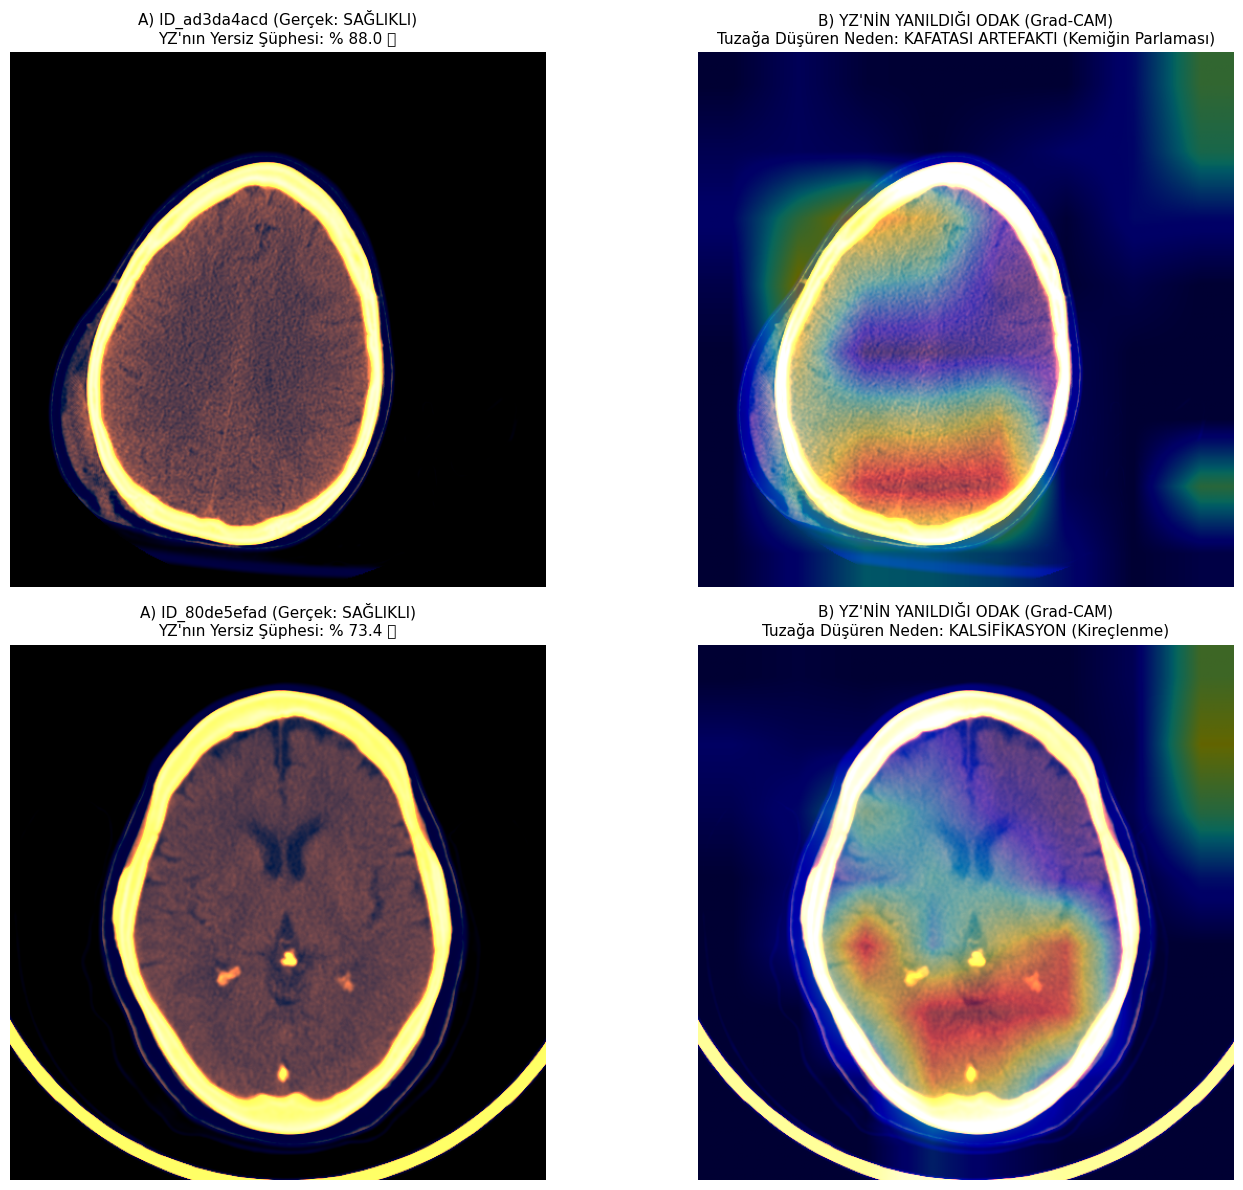


ðŸ‘¨â€âš•ï¸ OTOPSÄ° SONUCU: GÃ¶rsel kanÄ±tlanmÄ±ÅŸtÄ±r! Yapay zekalar beyindeki anatomik tuzaklarda 'Radyolog YÃ¶nlendirmesine' muhtaÃ§tÄ±r.


In [26]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pydicom

print("ðŸ•µï¸ OTOPSÄ° BAÅžLIYOR: TÄ±bbi YanÄ±lsama HaritalarÄ±nÄ±n (Error-Focused Grad-CAM) DeÅŸifresi...\n")

son_gorsel_katman_adi = "top_activation"

def isi_haritasi_cikar(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        # AsistanÄ±n o hatalÄ± kararÄ±nÄ± verirken "En Ã§ok ÅŸÃ¼phelendiÄŸi" noktaya kitlen
        pred_index = tf.argmax(preds[0]) 
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# SÄ±navda kandÄ±rÄ±lan iki saÄŸlÄ±klÄ± hastamÄ±zÄ± hafÄ±zadan Ã§ekiyoruz
# 2. Hasta (KemiÄŸe aldanan) -> Ä°ndeks 1
# 4. Hasta (KireÃ§lenmeye aldanan) -> Ä°ndeks 3
tuzaÄŸa_dusenler = [sinav_hastalar[1], sinav_hastalar[3]]
hata_tipleri = ["KAFATASI ARTEFAKTI (KemiÄŸin ParlamasÄ±)", "KALSÄ°FÄ°KASYON (KireÃ§lenme)"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, y_id in enumerate(tuzaÄŸa_dusenler):
    hedef_dosya = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/" + y_id + ".dcm"

    dataset = pydicom.dcmread(hedef_dosya)
    fields = [dataset[('0028','1050')].value, dataset[('0028','1051')].value,
              dataset[('0028','1052')].value, dataset[('0028','1053')].value]

    def get_first_local(x):
        if type(x) == pydicom.multival.MultiValue: return int(x[0])
        return int(x)

    _, _, inter, slope = [get_first_local(x) for x in fields]

    img = dataset.pixel_array.astype(float)
    red = window_image(img.copy(), 40, 80, inter, slope)
    green = window_image(img.copy(), 80, 200, inter, slope)
    blue = window_image(img.copy(), 600, 2800, inter, slope)

    rgb = np.zeros((img.shape[0], img.shape[1], 3))
    rgb[:,:,0], rgb[:,:,1], rgb[:,:,2] = red, green, blue

    rgb_resized = cv2.resize(rgb, (256, 256))
    img_array = np.expand_dims(rgb_resized, axis=0)

    # ---------------------------------------------
    # AsistanÄ±n o %88 ve %73 uydurma ÅŸÃ¼phesi nereden geliyor? IsÄ± HaritasÄ±nÄ± alalÄ±m.
    # ---------------------------------------------
    heatmap = isi_haritasi_cikar(img_array, bizim_model, son_gorsel_katman_adi)
    heatmap_resized = cv2.resize(heatmap, (rgb.shape[1], rgb.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    jet = plt.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]

    superimposed_img = jet_heatmap * 0.4 + rgb
    superimposed_img = np.clip(superimposed_img, 0, 1)

    tahmin_orani = bizim_model.predict(img_array, verbose=0)[0][0] * 100

    # Sol SÃ¼tun: Orijinal Ã‡izim
    ax_orig = axes[i, 0]
    ax_orig.imshow(rgb)
    ax_orig.set_title(f"A) {y_id} (GerÃ§ek: SAÄžLIKLI)\nYZ'nÄ±n Yersiz ÅžÃ¼phesi: % {tahmin_orani:.1f} ðŸš¨", fontsize=11)
    ax_orig.axis('off')

    # SaÄŸ SÃ¼tun: YZ YanÄ±lsamasÄ± (CSI Odak Ã‡izimi)
    ax_heat = axes[i, 1]
    ax_heat.imshow(superimposed_img)
    ax_heat.set_title(f"B) YZ'NÄ°N YANILDIÄžI ODAK (Grad-CAM)\nTuzaÄŸa DÃ¼ÅŸÃ¼ren Neden: {hata_tipleri[i]}", fontsize=11)
    ax_heat.axis('off')

plt.tight_layout()
plt.show()

print("\nðŸ‘¨â€âš•ï¸ OTOPSÄ° SONUCU: GÃ¶rsel kanÄ±tlanmÄ±ÅŸtÄ±r! Yapay zekalar beyindeki anatomik tuzaklarda 'Radyolog YÃ¶nlendirmesine' muhtaÃ§tÄ±r.")
